In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

from tqdm import tqdm
from numpy.typing import NDArray
import numpy as np
from astropy.io import fits
from astropy.io.fits.fitsrec import FITS_rec

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag

MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = config_psfy_flag(DATASET)

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

E_MIN, E_MAX = None, None

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET], E_min=E_MIN, E_max=E_MAX)
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

In [4]:
type EnergyRange = tuple[float, float]

def extract_flx(filepath: str | Path) -> tuple[NDArray, NDArray]:
    """Extracts energy bins and flux arrays from FITS file."""
    flx_rec: FITS_rec = fits.getdata(Path(filepath), ext=1, header=False)
    return flx_rec['EBINS'], flx_rec['FLUX'][:-1]

def get_eband_flx_fract(ebins: NDArray, flux: NDArray, eband: EnergyRange) -> float:
    """Computes the source flux fraction in given energy band."""
    low, high = eband
    band: NDArray = np.where((ebins >= low) & (ebins <= high))[0][:-1]
    return flux[band].sum() / flux.sum()

MFLX_FILE: str = 'RXTE-ASM_BeppoSAX-WFC_catalog_2-50keV_MeanAvgFluxCrablike.fits'
ENERGYBINS, MEANFLX_ARR = extract_flx(
    f'/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/camera_settings/{MFLX_FILE}'
)

def get_flx_fracts(energy_bands: tuple[EnergyRange, ...]) -> tuple[float, ...]:
    """Computes the source flux fractions in selected energy bands."""
    if (E_MIN is not None) and (E_MAX is not None):
        band: NDArray = np.where((ENERGYBINS >= E_MIN) & (ENERGYBINS <= E_MAX))[0][:-1]
        _mean_flx_arr = MEANFLX_ARR[band]
    else:
        _mean_flx_arr = MEANFLX_ARR
    
    fractions: tuple[float, ...] = tuple(
        get_eband_flx_fract(ENERGYBINS, _mean_flx_arr, eband) for eband in energy_bands
    )
    
    return fractions

In [5]:
from bloodmoon.images import fshift
from bloodmoon.mask import decode
from bloodmoon.optim import _detector_footprint_cached
from bloodmoon.optim import apply_detector_resolution, apply_vignetting

type CoordSky = tuple[float, float]


def _project_mask_pattern(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
) -> NDArray:
    """Projects the camera mask pattern on the detector plane."""
    pxdimy, pxdimx = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    fr, fc = (
        (-1.0) * shift_y / pxdimy,
        (-1.0) * shift_x / pxdimx,
    )
    mask_shifted = fshift(camera.mask.astype(float), fr, fc)
    return mask_shifted

def _process_mask_pattern(
    camera: CodedMaskCamera,
    mask_pattern: NDArray,
    shift_x: float,
    shift_y: float,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Applies instrumental effects to the mask pattern projection."""
    mp_vignetted: NDArray = (
        apply_vignetting(camera, mask_pattern, shift_x, shift_y)
        if vignetting else mask_pattern
    )
    mp_psfy: NDArray = (
        apply_detector_resolution(camera, mp_vignetted)
        if psfy else mp_vignetted
    )
    return mp_psfy

def _extract_detector(
    camera: CodedMaskCamera,
    mask_projection: NDArray,
) -> NDArray:
    """
    Extracts the detector image from the mask pattern projection on the detector plane.
    """
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = mask_projection[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    detector /= np.sum(detector)
    return detector


def model_source_sg(
    camera: CodedMaskCamera,
    params: dict[EnergyRange, CoordSky],
    vignetting: bool = True,
    psfy: bool = True,
) -> NDArray:
    """
    Generates a source detector image as superimposition
    of shadowgrams in given energy bands.
    """
    flx_fracts: tuple[float, ...] = get_flx_fracts(tuple(params.keys()))
    detector: NDArray = np.zeros(camera.shape_detector)
    _sx, _sy = tuple(params.values())[0]
    for frc, shifts in zip(flx_fracts, tuple(params.values())):
        # shift mask pattern wrt the energy band
        _shifted = _project_mask_pattern(camera, *shifts)
        # apply instr effects
        _processed = _process_mask_pattern(camera, _shifted, _sx, _sy, vignetting, psfy)
        # extract source detector image and weight it with eband flux fraction
        detector += (frc * _extract_detector(camera, _processed))
    
    return detector


def model_source_sky(
    camera: CodedMaskCamera,
    params: dict[EnergyRange, CoordSky],
    counts: float,
    vignetting: bool = True,
    psfy: bool = True,
) -> NDArray:
    """Generate a model of the reconstructed sky image for a point source."""
    detector = model_source_sg(
        camera, params, vignetting=vignetting, psfy=psfy,
    )
    return decode(camera, counts * detector)

In [6]:
from typing import Callable
from dataclasses import dataclass

from scipy.optimize import curve_fit

from bloodmoon.coords import pos2shift
from bloodmoon.optim import process_skyimg

@dataclass
class OptParams:
    """Optimisation results."""
    coords: dict[EnergyRange, CoordSky]
    cts: float
    covar: NDArray


def config_optimiser(
    camera: CodedMaskCamera,
    ebands: tuple[EnergyRange, ...],
    vignetting: bool = True,
    psfy: bool = True,
    camera_coding_power: float = 0.85,
) -> Callable[[NDArray, tuple[int, int], bool], OptParams]:
    """
    Configures the IROS optimiser for source parameters fitting.
    """
    def _ModelShiftFluence(
        arg_sky: tuple[int, int],
    ) -> Callable[[NDArray, *tuple[float, ...]], NDArray]:
        """
        Initialises the source model.
        """
        def model_source(x: NDArray, sx0, sy0, cts) -> NDArray:  # sx1, sy1, sx2, sy2, sx3, sy3, sx4, sy4,
            """Models the source sky image."""
            params: dict[EnergyRange, CoordSky] = {
                ebands[0]: (sx0, sy0),
                #ebands[1]: (sx1, sy1),
                #ebands[2]: (sx2, sy2),
                #ebands[3]: (sx3, sy3),
                #ebands[4]: (sx4, sy4),
            }
            modeled: NDArray = model_source_sky(
                camera, params, cts, vignetting, psfy,
            )
            return process_skyimg(camera, modeled, arg_sky)
        
        return model_source
    
    def optimise(
        sky: NDArray,
        arg_sky: tuple[int, int],
        verbose: bool = False,
    ) -> OptParams:
        """
        Performs the optimization to fit a point source model to sky image data.
        """
        model_source = _ModelShiftFluence(arg_sky)

        # setup `curve_fit` params
        # - setup source data + std
        sky_ydata = process_skyimg(camera, sky, arg_sky)
        _sky_ydata_sigma = np.sqrt(np.clip(sky_ydata, a_min=0.0, a_max=None))
        sky_ydata_sigma = _sky_ydata_sigma.max() - _sky_ydata_sigma + 1
        # - extract source coords and counts starting values
        sx_start, sy_start = pos2shift(camera, *arg_sky)
        sky_peak = sky[*arg_sky]
        cts_start = (
            sky_peak / camera_coding_power if psfy else sky_peak
        )
        start_params_vals = np.array(
            [sx_start, sy_start] * len(ebands) + [cts_start]
        )
        # - setup fit params boundaries
        #    - the shifts are allowed to fluctuate in a small pixel box since
        #      the extracted position is close enough to the true source pos
        #      A small box also account for superimposed or close sources,
        #      which may introduce biases in the source fit procedure
        #    - the box is built from the digital upsampling since in the worst
        #      case (source at 45 deg wrt optical axis) the high energy detected
        #      photons median absorption distance is 225um. The projection of this
        #      distance on the camera plane is always smaller than `px_size / ups`  
        #    - the fluence cannot be smaller than the one observed at the peak,
        #      and we insert a lower value just for precaution (if simulating
        #      for example an infinite detector spatial resolution)
        px_dim_x, px_dim_y = (
            camera.specs.mask_deltax / camera.upscale_f.x,
            camera.specs.mask_deltay / camera.upscale_f.y,
        )
        dx, dy = 2 * camera.upscale_f.x, 2 * camera.upscale_f.y
        bounds = [
            tuple(
                [
                    max(sx_start - dx * px_dim_x, camera.bins_sky.x[0]),
                    max(sy_start - dy * px_dim_y, camera.bins_sky.y[0]),
                ] * len(ebands) + [0.95 * sky_peak]
            ),
            tuple(
                [
                    min(sx_start + dx * px_dim_x, camera.bins_sky.x[-1]),
                    min(sy_start + dy * px_dim_y, camera.bins_sky.y[-1]),
                ] * len(ebands) + [1.25 * sky_peak]
            ),
        ]
        # - setup least squares kwargs
        lsq_kwargs = {
            'jac': '3-point',
            'ftol': 1e-8,
            'xtol': 1e-8,
            'x_scale': 'jac',
            'loss': 'linear',
        }

        # perform optimisation
        popt, pcov, info, msg, iflag = curve_fit(
            model_source,
            xdata=np.arange(len(sky_ydata)),
            ydata=sky_ydata,
            p0=start_params_vals,
            sigma=sky_ydata_sigma,
            bounds=bounds,
            method='trf',
            full_output=True,
            **lsq_kwargs,
        )
        # store results and verbose
        coords: dict[EnergyRange, CoordSky] = {
            eband: tuple(shifts) for eband, shifts in zip(ebands, popt[:-1].reshape(len(ebands), 2))
        }
        params: OptParams = OptParams(
            coords=coords,
            cts=float(popt[-1]),
            covar=pcov,
        )
        if verbose:
            sx, sy, *_, cts = map(float, popt)
            dsx, dsy, *_, df = map(float, np.sqrt(np.diag(pcov)))
            print(
                f'\n'
                f'## Optimisation Results:\n'
                f'  - fluence START: {cts_start}\n'
                f'  - shifts START (x, y): {sx_start}, {sy_start}\n'

                f'  - fluence OPTIM.: {cts} +/- {df}\n'
                f'  - shifts OPTIM. (x, y): {sx} +/- {dsx}, {sy} +/- {dsy}\n'

                f'  - fluence GAIN %: {(cts - cts_start) * 100 / cts_start:.3f}\n'
                f'  - shift_x GAIN %: {np.sign(sx_start) * (sx - sx_start) * 100 / sx_start:.3f}\n'
                f'  - shift_y GAIN %: {np.sign(sy_start) * (sy - sy_start) * 100 / sy_start:.3f}'
            )
            routine_status = [
                'Convergence in chi-square values',
                'Convergence in parameter values',
                'Convergence in both chi-square and parameter values',
                'Convergence in orthogonality',
            ]
            print(
                f'## Fit Report:\n'
                f'  - func calls (also # of iters): {info['nfev']}\n'
                f'  - procedure msg (`ftol`, `xtol` = {lsq_kwargs['ftol']}, {lsq_kwargs['xtol']}): {msg}\n'
                f'  - success status {iflag}: {routine_status[iflag - 1]}\n'
            )

        return params
    
    return optimise

In [7]:
from typing import Any

@dataclass
class Candidate:
    """
    Source candidate parameters container.
    """
    coords: dict[EnergyRange, CoordSky]
    cts: float
    snr: float


def config_IROS_operations(
    camera: CodedMaskCamera,
    optimiser: Callable[[NDArray, tuple[int, int], bool], OptParams],
    snr_threshold: float = 0.0,
    vignetting: bool = True,
    psfy: bool = True,
) -> tuple[
    Callable[[NDArray, NDArray, int], tuple[int, int] | bool],
    Callable[[tuple[int, int], NDArray, NDArray], Candidate],
    Callable[[Candidate, NDArray], NDArray],
]:
    """
    Configures the operative funcs (source finder, fit and subtractor) for the IROS procedure.
    """
    SETUP: dict[str, Any] = {
        'slit_mask_fine': int(
            camera.specs.slit_deltax * camera.upscale_f.x / camera.specs.mask_deltax
        ),
        'slit_mask_coarse': int(
            camera.specs.slit_deltay * camera.upscale_f.y / camera.specs.mask_deltay
        ),
        'skymap_mask': np.ones(camera.shape_sky, dtype=int),
    }

    def _update_skymap_mask(arg_sky: tuple[int, int]) -> None:
        """
        Updates the skymap mask with the new candidate position by covering the candidate
        half-PSF profile (to account for the camera angular resolution of a source).
        """
        rows = slice(
            arg_sky[0] - SETUP['slit_mask_coarse'] // 2, arg_sky[0] + SETUP['slit_mask_coarse'] // 2 + 1,
        )
        cols = slice(
            arg_sky[1] - SETUP['slit_mask_fine'] // 2, arg_sky[1] + SETUP['slit_mask_fine'] // 2 + 1,
        )
        SETUP['skymap_mask'][rows, cols] = 0
        return None
    
    def finder(
        sky: NDArray,
        snr: NDArray,
        batch: int = 1000,
    ) -> tuple[int, int] | bool:
        """
        Returns the position of a valid IROS candidate inside the sky image.
        """
        reservoir = np.array(
            [np.unravel_index(id_, sky.shape) for id_ in np.argsort(sky, axis=None)[-batch:]]
        )
        for arg_sky in reservoir[::-1]:
            if (snr[*arg_sky] > snr_threshold) and SETUP['skymap_mask'][*arg_sky]:
                _update_skymap_mask(arg_sky)
                return tuple(arg_sky)
        return False
    
    def fitter(
        arg_sky: tuple[int, int],
        sky: NDArray,
        snr: NDArray,
    ) -> Candidate:
        """Performs the optimisation of the source candidate params."""
        try:
            params: OptParams = optimiser(
                sky=sky,
                arg_sky=arg_sky,
                verbose=True,
            )
        except Exception as e:
            raise RuntimeError(f"Optimization failed: {str(e)}") from e
        
        significance = float(snr[*arg_sky])
        return Candidate(params.coords, params.cts, significance)
    
    def subtractor(
        candidate: Candidate,
        detector: NDArray,
    ) -> NDArray:
        """Subtracts candidate from detector image."""
        sg_model = model_source_sg(
            camera=camera,
            params=candidate.coords,
            vignetting=vignetting,
            psfy=psfy,
        )
        residual = detector - candidate.cts * sg_model
        return residual
    
    return finder, fitter, subtractor

In [8]:
from typing import Iterable
import warnings

from bloodmoon.mask import decode
from bloodmoon.mask import variance
from bloodmoon.mask import snratio


def iros_singleCAM(
    detector: NDArray,
    camera: CodedMaskCamera,
    energy_bands: tuple[EnergyRange, ...],
    max_iterations: int = 5,
    snr_threshold: float = 5.0,
    vignetting: bool = True,
    psfy: bool = True,
    varmap: NDArray | None = None,
) -> Iterable[tuple[Candidate, NDArray]]:
    """
    Performs the Iterative Removal of Sources (IROS) algorithm for a single coded-mask
    camera of the Wide Field Monitor observations.
    """
    # operations setup
    optimiser = config_optimiser(
        camera, energy_bands, vignetting, psfy,
    )
    find_candidate, fit_candidate_params, subtract = config_IROS_operations(
        camera, optimiser, snr_threshold, vignetting, psfy,
    )
    # arrs setup
    detector_ = detector.copy()
    skymap = decode(camera, detector)
    varmap = (
        varmap if varmap is not None
        else variance(camera, detector)
    )
    # looping as there's no tomorrow
    for i in range(max_iterations):
        snrmap = snratio(skymap, varmap)
        candidate_pos = find_candidate(skymap, snrmap)

        if not candidate_pos:
            print("\nNo candidates left...")
            break

        try:
            source = fit_candidate_params(candidate_pos, skymap, snrmap)
        except RuntimeError as e:
            warnings.warn(f"Optimizer failed at iteration {i}:\n\n{e}")
            continue

        detector_ = subtract(source, detector_)
        skymap = decode(camera, detector_)
        yield (source, skymap)

In [9]:
from bloodmoon.coords import shift2pos


def run(loop: Iterable) -> tuple[Candidate, ...]:
    """Runs the IROS loop."""
    print("# Running IROS loop...")
    candidates = tuple(cand for cand, _ in tqdm(loop))
    print("# End IROS loop...\n")
    return candidates

def retrieve_skyimg_comps(camera: CodedMaskCamera, source: Candidate) -> tuple[NDArray, ...]:
    """Computes the components of the source in energy bands."""
    _flx_fracts = get_flx_fracts(tuple(source.coords.keys()))
    cts_vals: tuple[float, ...] = tuple(frc * source.cts for frc in _flx_fracts)
    # compute components shadowgrams
    sg_comps: tuple[NDArray, ...] = tuple(
        _project_mask_pattern(camera, *shifts) for shifts in tuple(source.coords.values())
    )
    _sx, _sy = tuple(source.coords.values())[0]
    sg_comps = map(
        lambda sg: _process_mask_pattern(camera, sg, _sx, _sy, VIGNETTING, PSFY),
        sg_comps,
    )
    # extract detectors
    detectors: tuple[NDArray, ...] = map(
        lambda proj: _extract_detector(camera, proj),
        sg_comps,
    )
    # compute sky components
    sky_comps: tuple[NDArray, ...] = tuple(
        decode(camera, cts * det) for cts, det in zip(cts_vals, detectors)
    )
    return sky_comps

def plot_results(
    true_sky: NDArray,
    candidates: tuple[Candidate, ...],
    camera: CodedMaskCamera,
    energy_bands: tuple[EnergyRange, ...],
    save_to: str | Path | None = None,
) -> None:
    """Plots energy band IROS results."""
    true_sky_ = true_sky.copy()
    res_ground = np.zeros_like(true_sky_)
    _slit_fine, _slit_coarse = ds.psf_extension(camera)
    crp = (
        _slit_coarse + 5 * camera.upscale_f.y,
        _slit_fine + 2 + camera.upscale_f.x,
    )

    for idx, cand in enumerate(candidates):
        _ebands_clrs = [
            'OrangeRed', 'Gold', 'Lawngreen', 'DodgerBlue', 'm',
        ]
        pos: tuple[int, int] = shift2pos(camera, *cand.coords[energy_bands[0]])
        sg_comps: tuple[NDArray, ...] = retrieve_skyimg_comps(camera, cand)
        modeled: NDArray = sum(sg_comps)
        sourceID: str = f'run_s{idx}'
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=pos,
            crp=crp,
            ylabel='counts [ph]',
            labels=('true', 'IROS'),
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(res_ground, true_sky_ - modeled),
            pos=pos,
            crp=crp,
            ylabel='residues',
            labels=['', 'true - IROS'],
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile_res')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(true_sky_, *sg_comps),
            pos=pos,
            crp=crp,
            ylabel='counts [ph]',
            labels=['true'] + [f'$\\Delta$E = {eband} keV' for eband in energy_bands],
            color=['#d9d9d9'] + _ebands_clrs,
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_ebands')
                if save_to is not None else None
            ),
        )
        true_sky_ -= modeled

    return None

In [10]:
energy_bands: tuple[EnergyRange, ...] = (
    (2.0, 50.0),
)
max_iterations: int = 5
snr_threshold: float = 5.0

detector: NDArray = count(wfm, sdlA.DLdata)[0]


iros_loop = iros_singleCAM(
    detector=detector,
    camera=wfm,
    energy_bands=energy_bands,
    max_iterations=max_iterations,
    snr_threshold=snr_threshold,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
candidates: tuple[Candidate, ...] = run(iros_loop)

## USING BULK MASK with 1.5 mm cover ##
# Running IROS loop...


1it [00:10, 10.49s/it]


## Optimisation Results:
  - fluence START: 920007.0587613162
  - shifts START (x, y): -108.375, 62.5
  - fluence OPTIM.: 839513.5587808887 +/- 22.61399361360116
  - shifts OPTIM. (x, y): -108.43686315008101 +/- 0.00021093036002248775, 62.703396889316984 +/- 0.002716919925443543
  - fluence GAIN %: -8.749
  - shift_x GAIN %: -0.057
  - shift_y GAIN %: 0.325
## Fit Report:
  - func calls (also # of iters): 13
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): `xtol` termination condition is satisfied.
  - success status 3: Convergence in both chi-square and parameter values



2it [00:28, 14.87s/it]


## Optimisation Results:
  - fluence START: 188385.45517148843
  - shifts START (x, y): 94.875, -56.0
  - fluence OPTIM.: 176848.03976341165 +/- 154.54674624266212
  - shifts OPTIM. (x, y): 94.95448371562597 +/- 0.0002491584718492595, -55.84731257604513 +/- 0.004035564546268487
  - fluence GAIN %: -6.124
  - shift_x GAIN %: 0.084
  - shift_y GAIN %: 0.273
## Fit Report:
  - func calls (also # of iters): 28
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality



...


## Optimisation Results:
  - fluence START: 151681.36904253246
  - shifts START (x, y): 22.0, 63.5
  - fluence OPTIM.: 161161.4525688955 +/- 282.1167437656093
  - shifts OPTIM. (x, y): 21.967683267504018 +/- 0.00032634621521930194, 63.812343362574474 +/- 0.030749616103236795
  - fluence GAIN %: 6.250
  - shift_x GAIN %: -0.147
  - shift_y GAIN %: 0.492
## Fit Report:
  - func calls (also # of iters): 21
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): `xtol` termination condition is satisfied.
  - success status 3: Convergence in both chi-square and parameter values



4it [00:56, 14.16s/it]


## Optimisation Results:
  - fluence START: 132779.17478546343
  - shifts START (x, y): -104.875, -22.5
  - fluence OPTIM.: 126583.81327335938 +/- 71.12286172099164
  - shifts OPTIM. (x, y): -104.96844139297227 +/- 0.00012513594519604121, -22.305483245331754 +/- 0.005129226223230849
  - fluence GAIN %: -4.666
  - shift_x GAIN %: -0.089
  - shift_y GAIN %: 0.865
## Fit Report:
  - func calls (also # of iters): 19
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality



5it [01:03, 12.71s/it]


## Optimisation Results:
  - fluence START: 126048.12258627464
  - shifts START (x, y): -73.75, -46.5
  - fluence OPTIM.: 119201.40926333275 +/- 128.28004660628991
  - shifts OPTIM. (x, y): -73.74660586921254 +/- 0.00023675650527315038, -46.80482934808529 +/- 0.004410558788831273
  - fluence GAIN %: -5.432
  - shift_x GAIN %: 0.005
  - shift_y GAIN %: -0.656
## Fit Report:
  - func calls (also # of iters): 9
  - procedure msg (`ftol`, `xtol` = 1e-08, 1e-08): Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality

# End IROS loop...



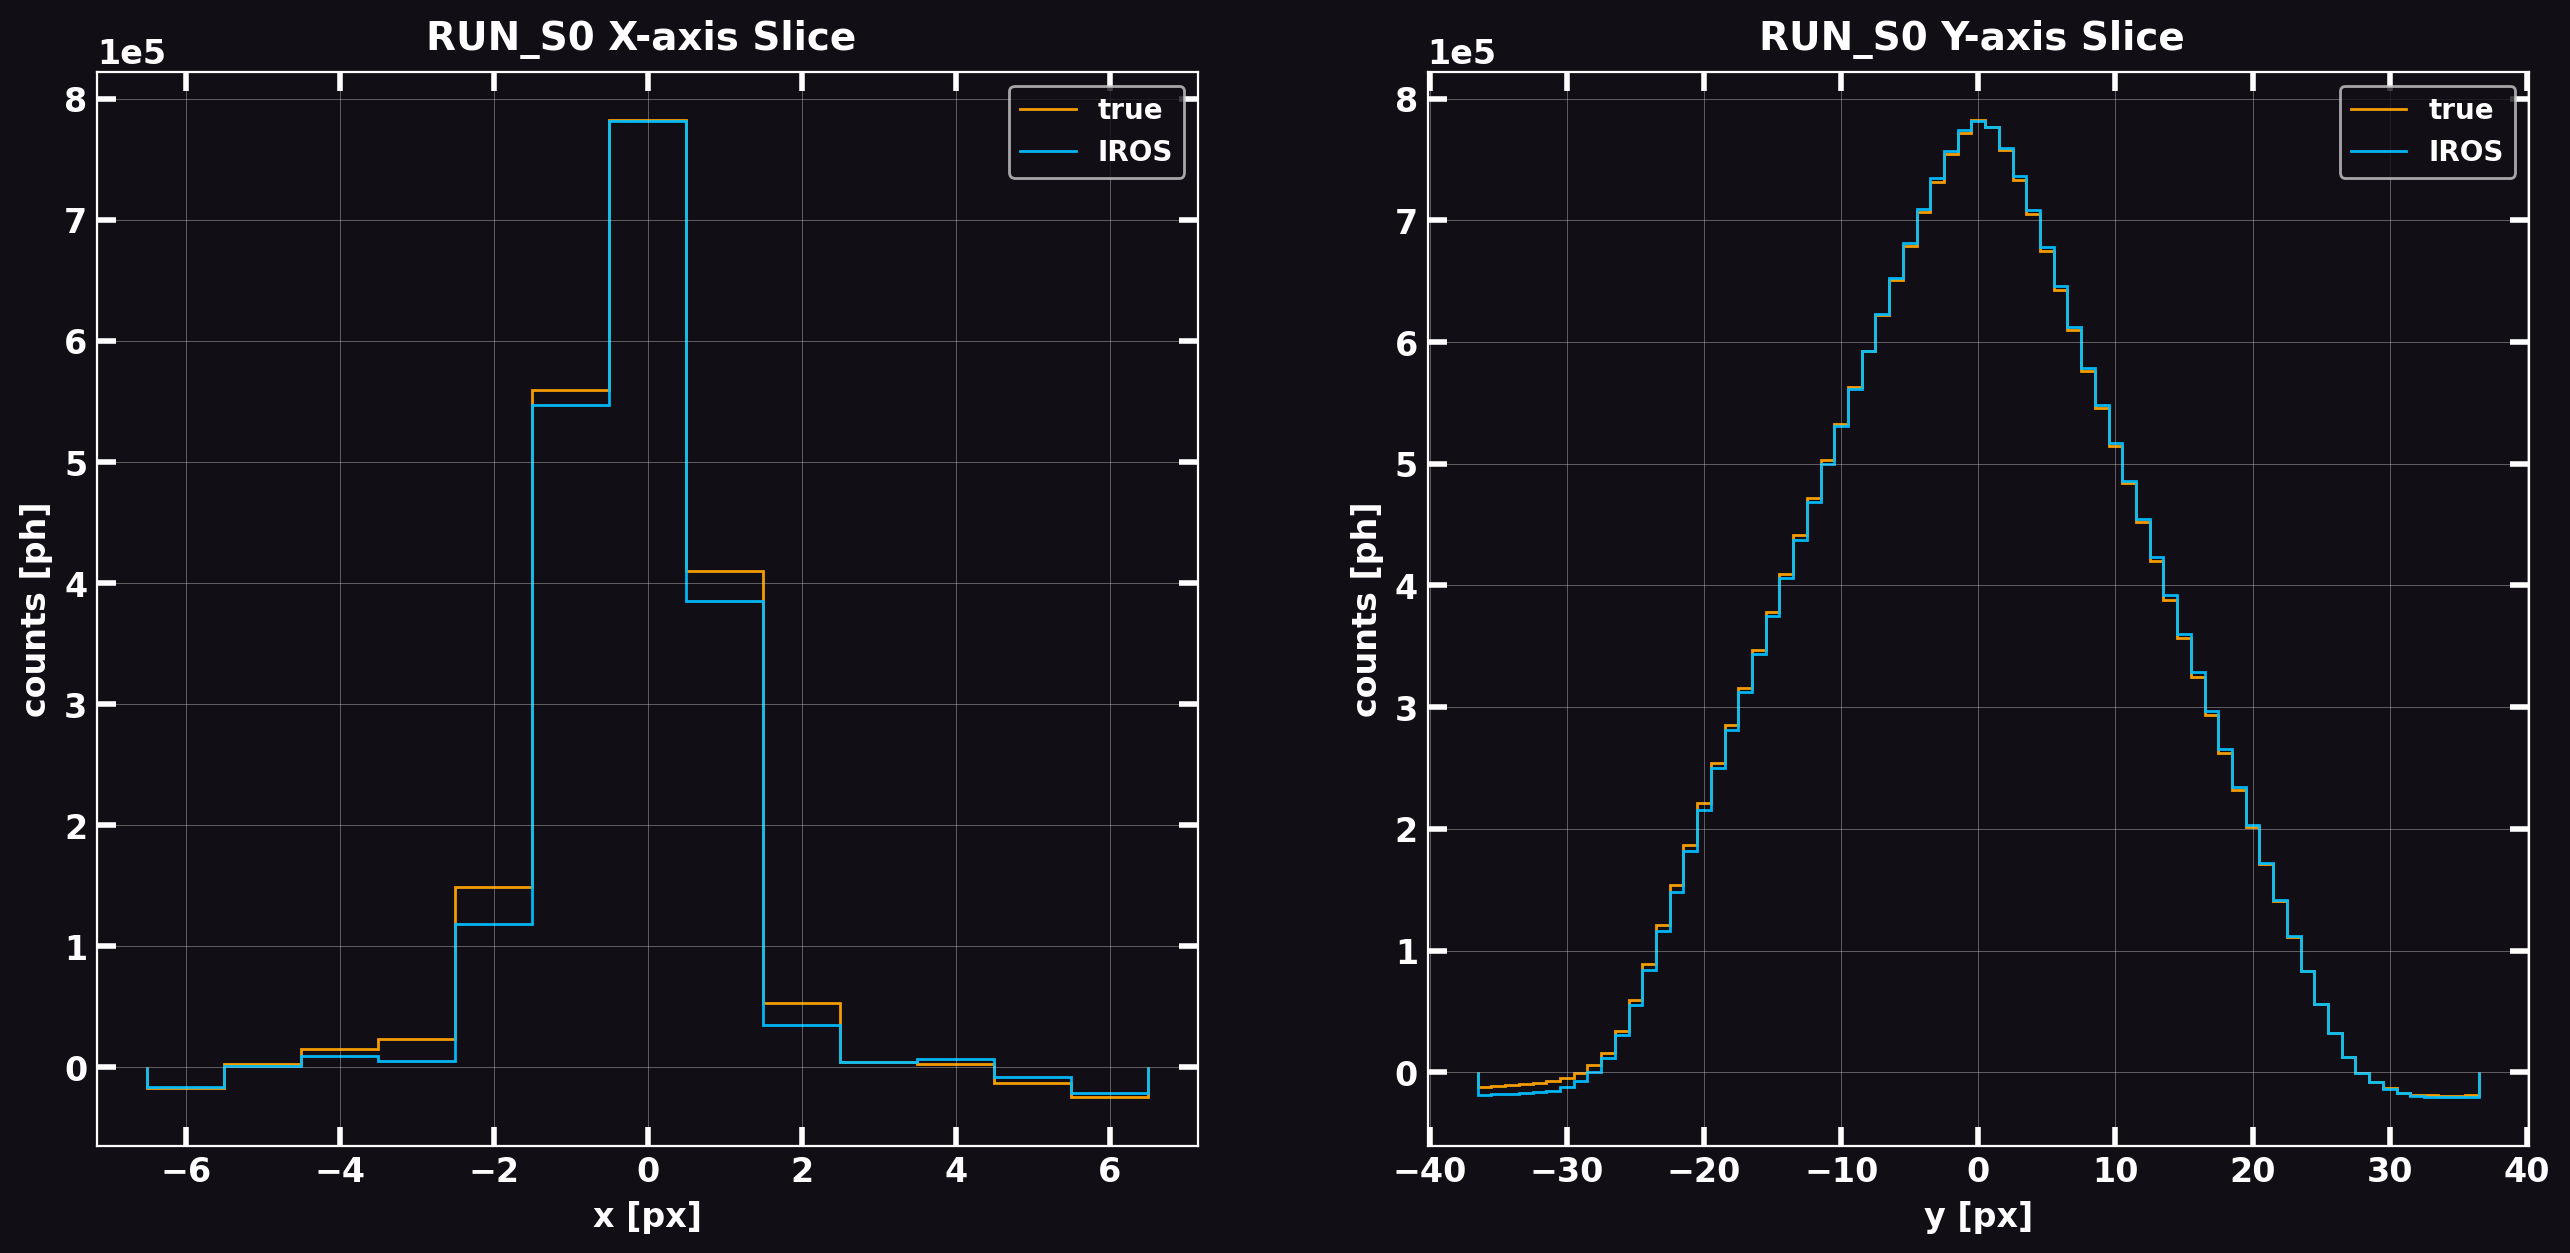

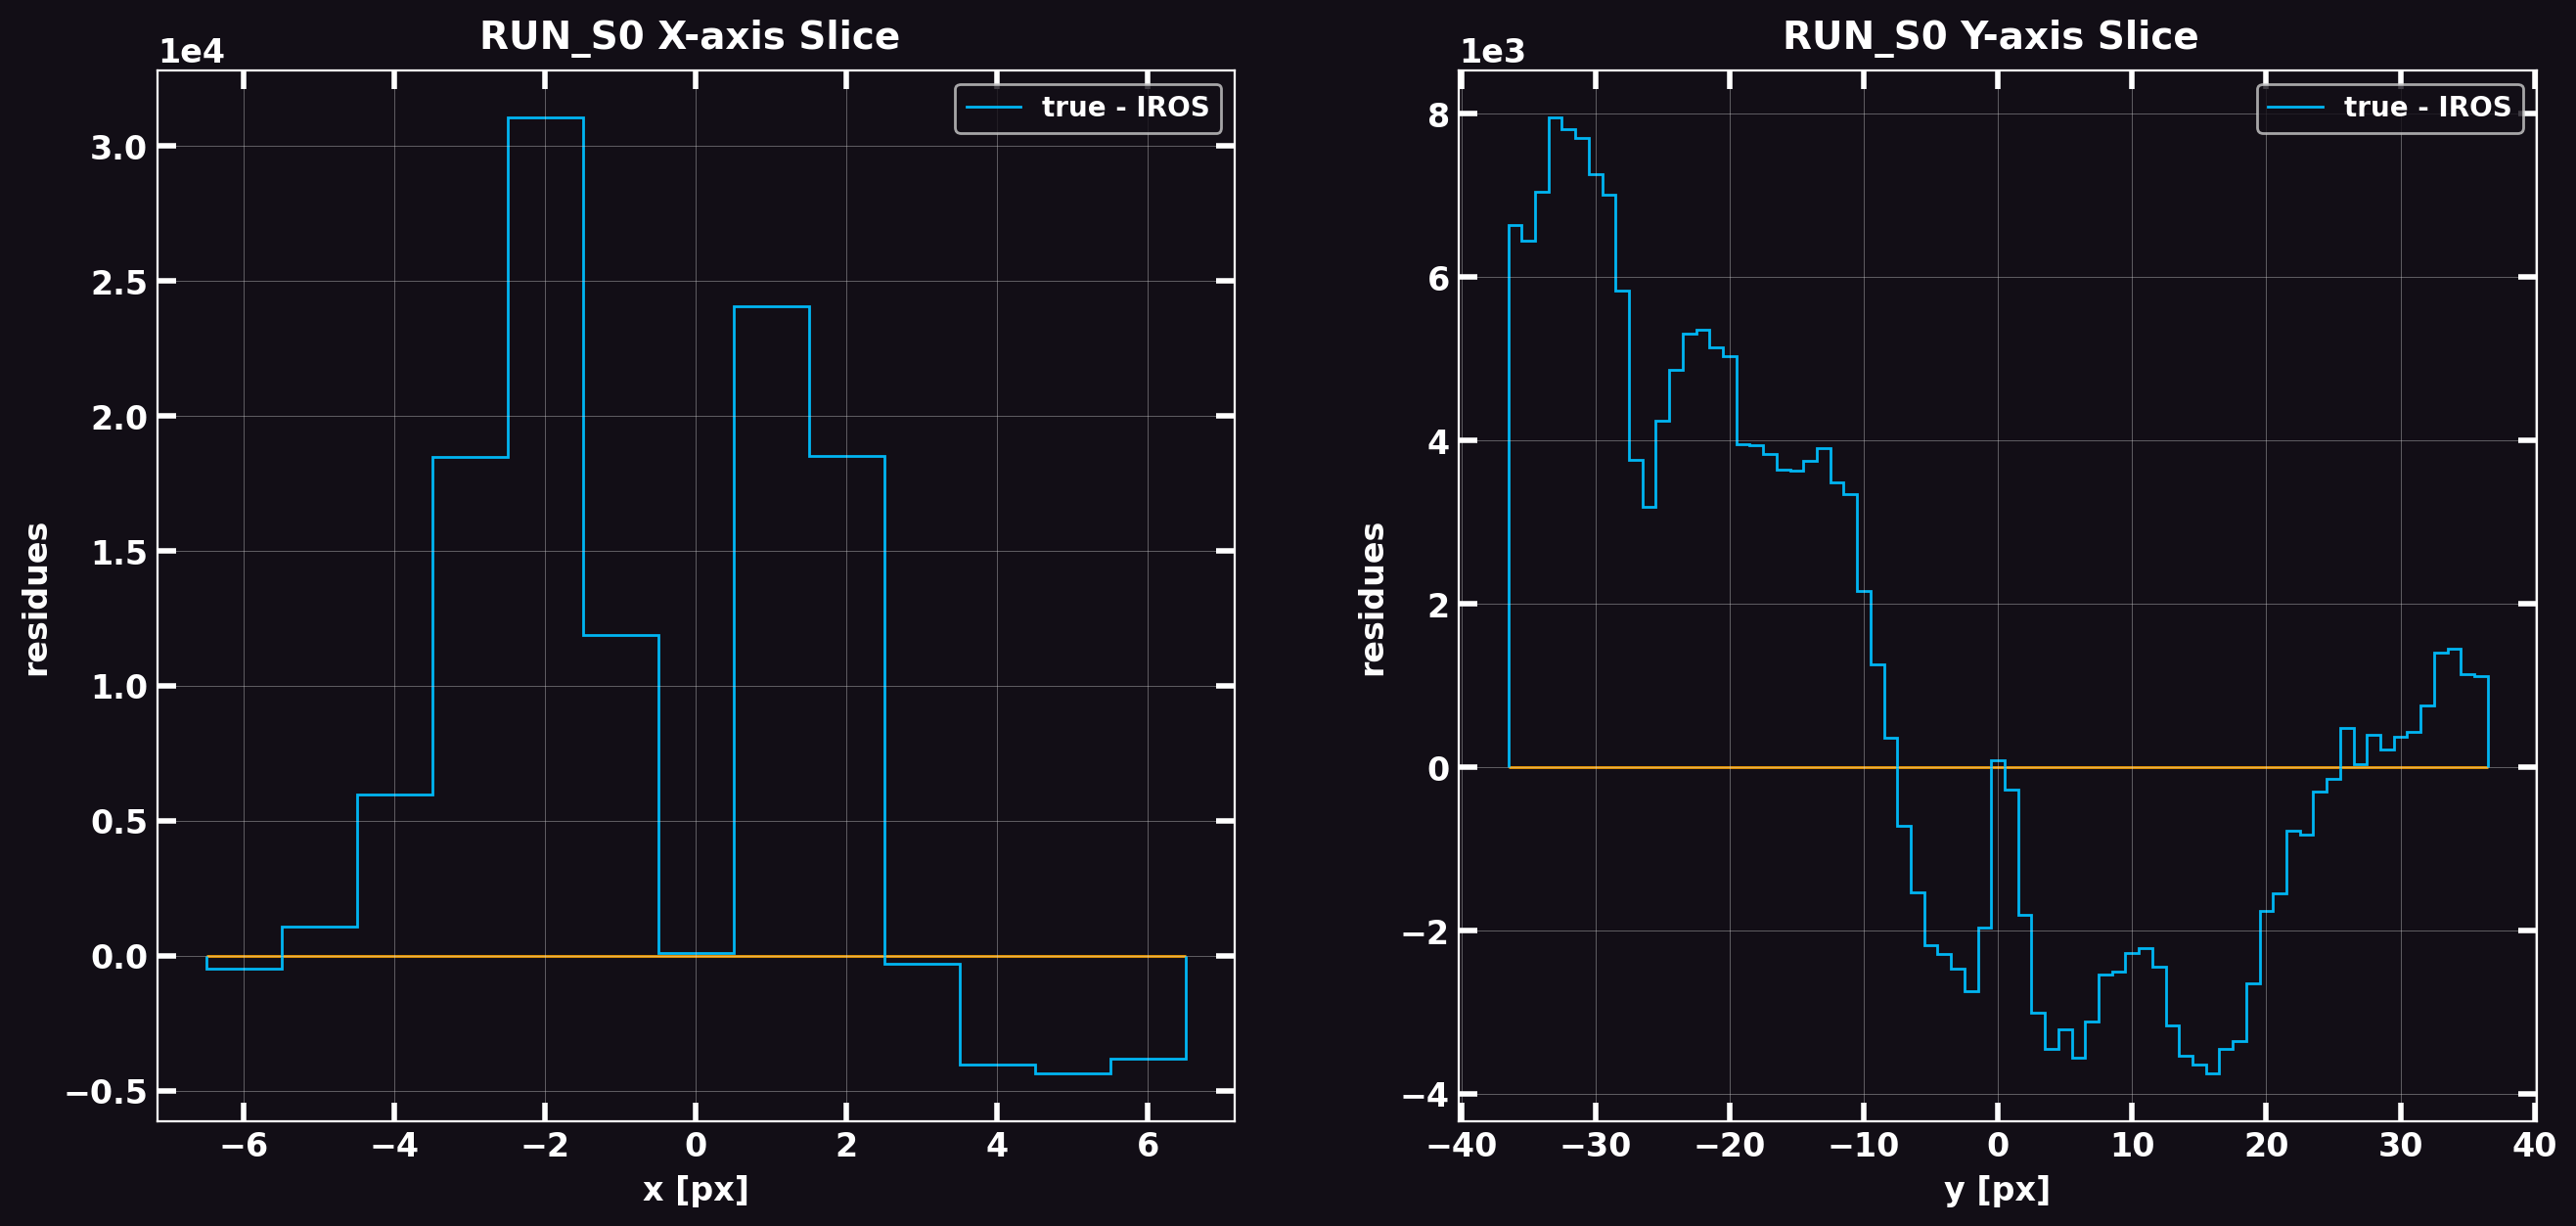

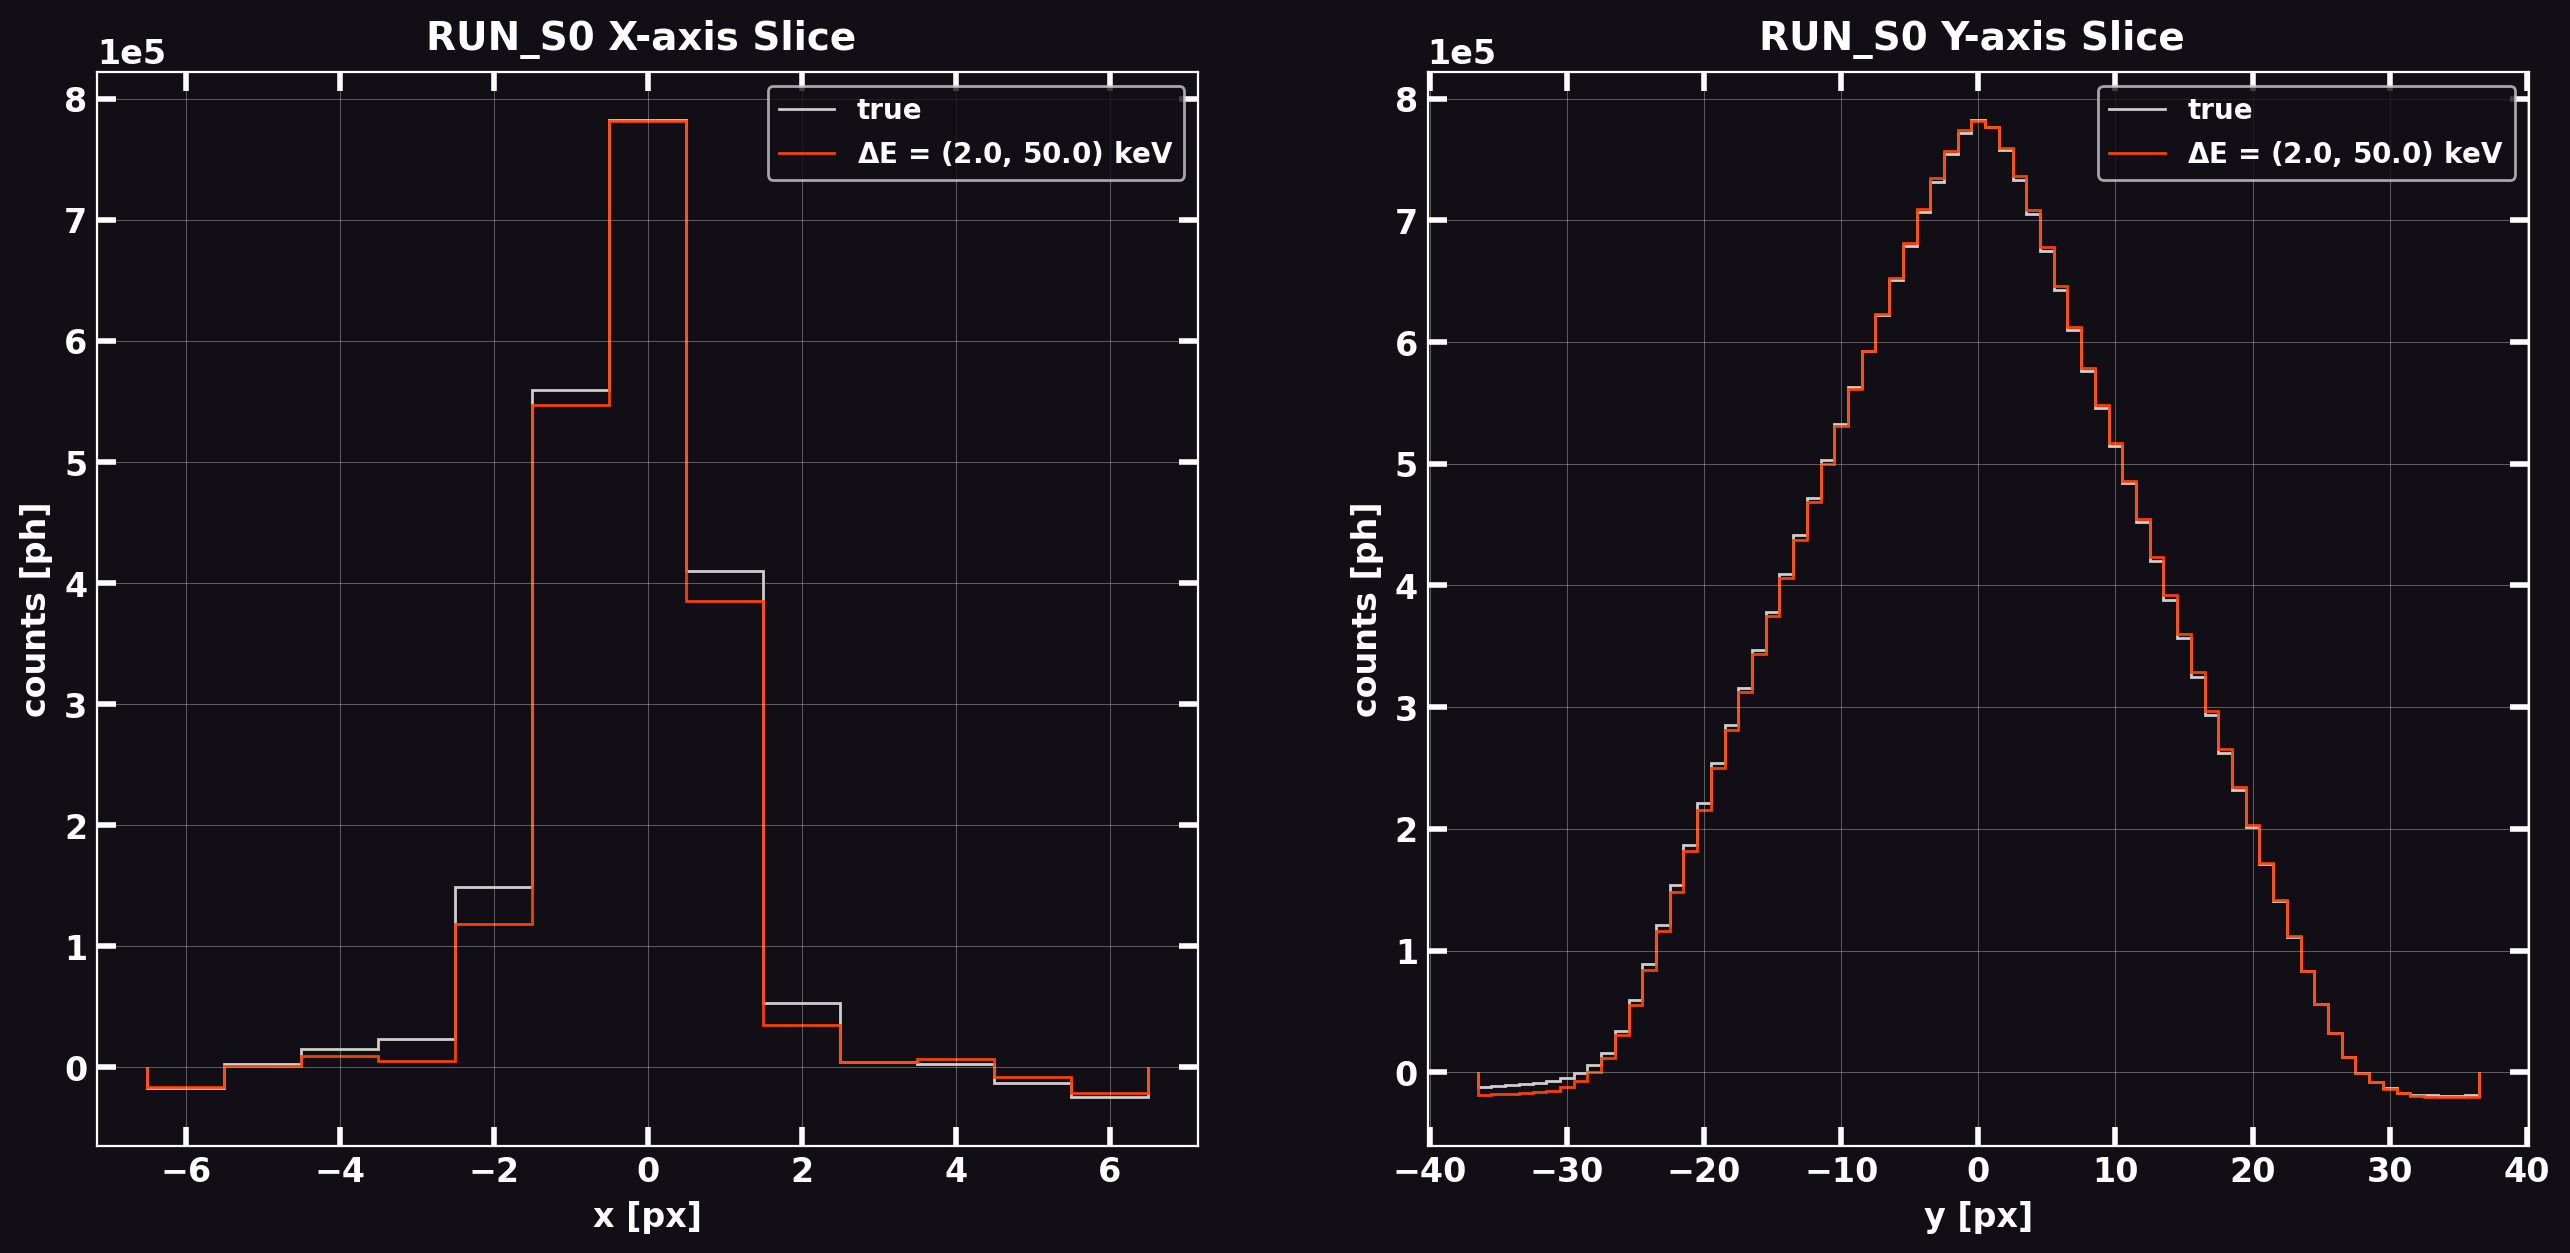

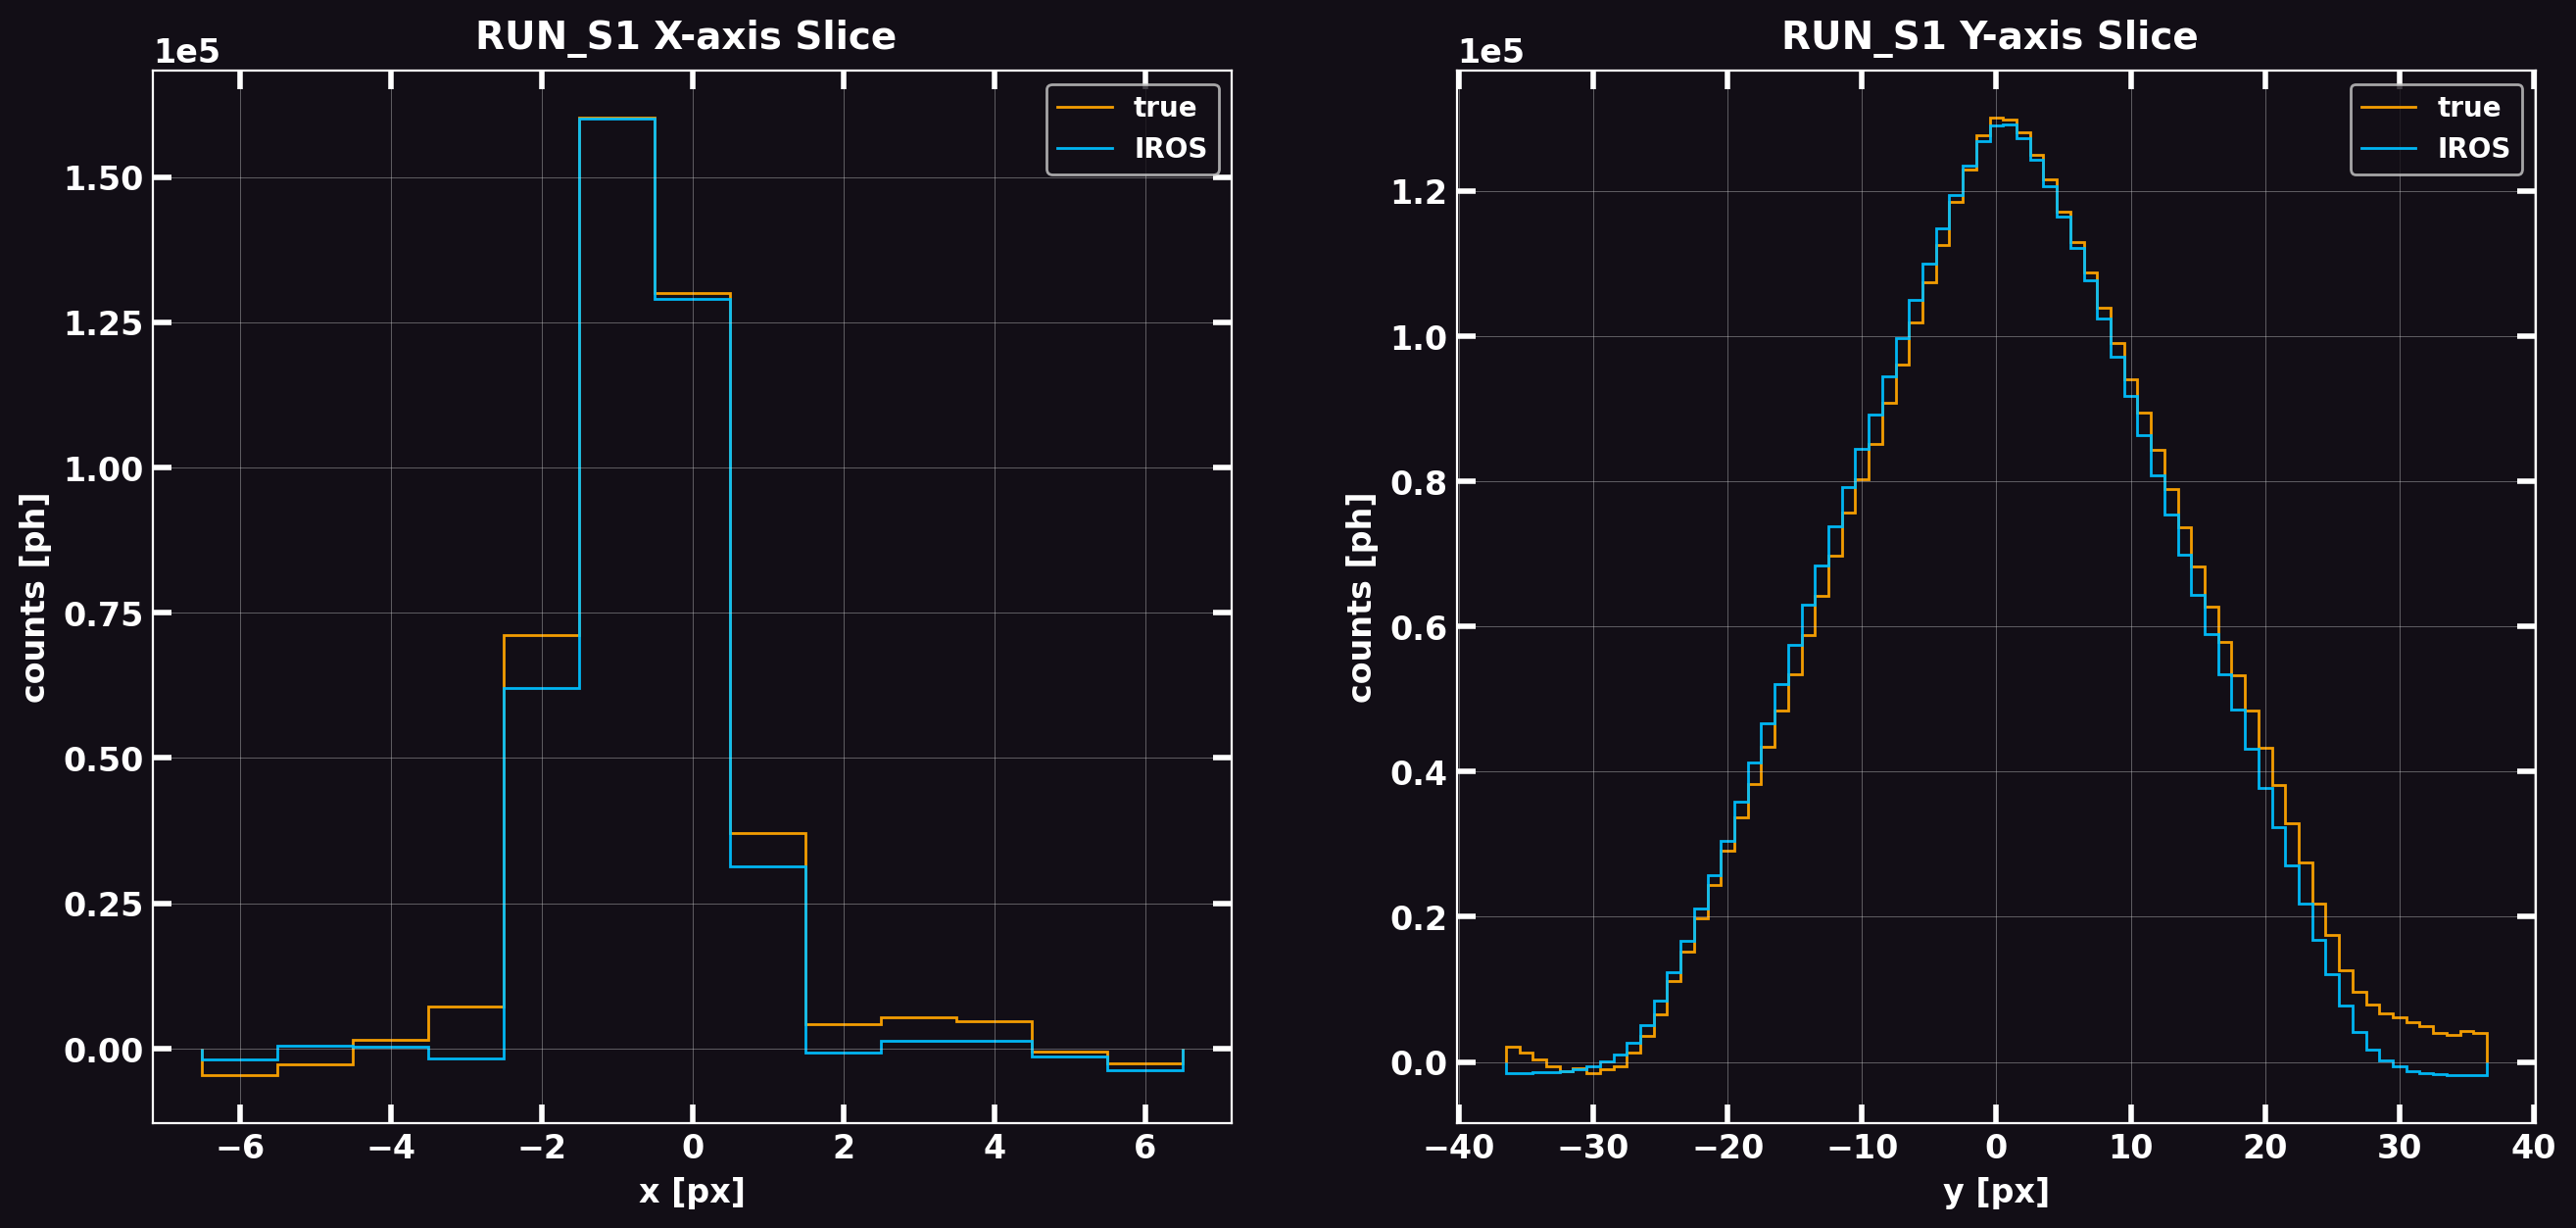

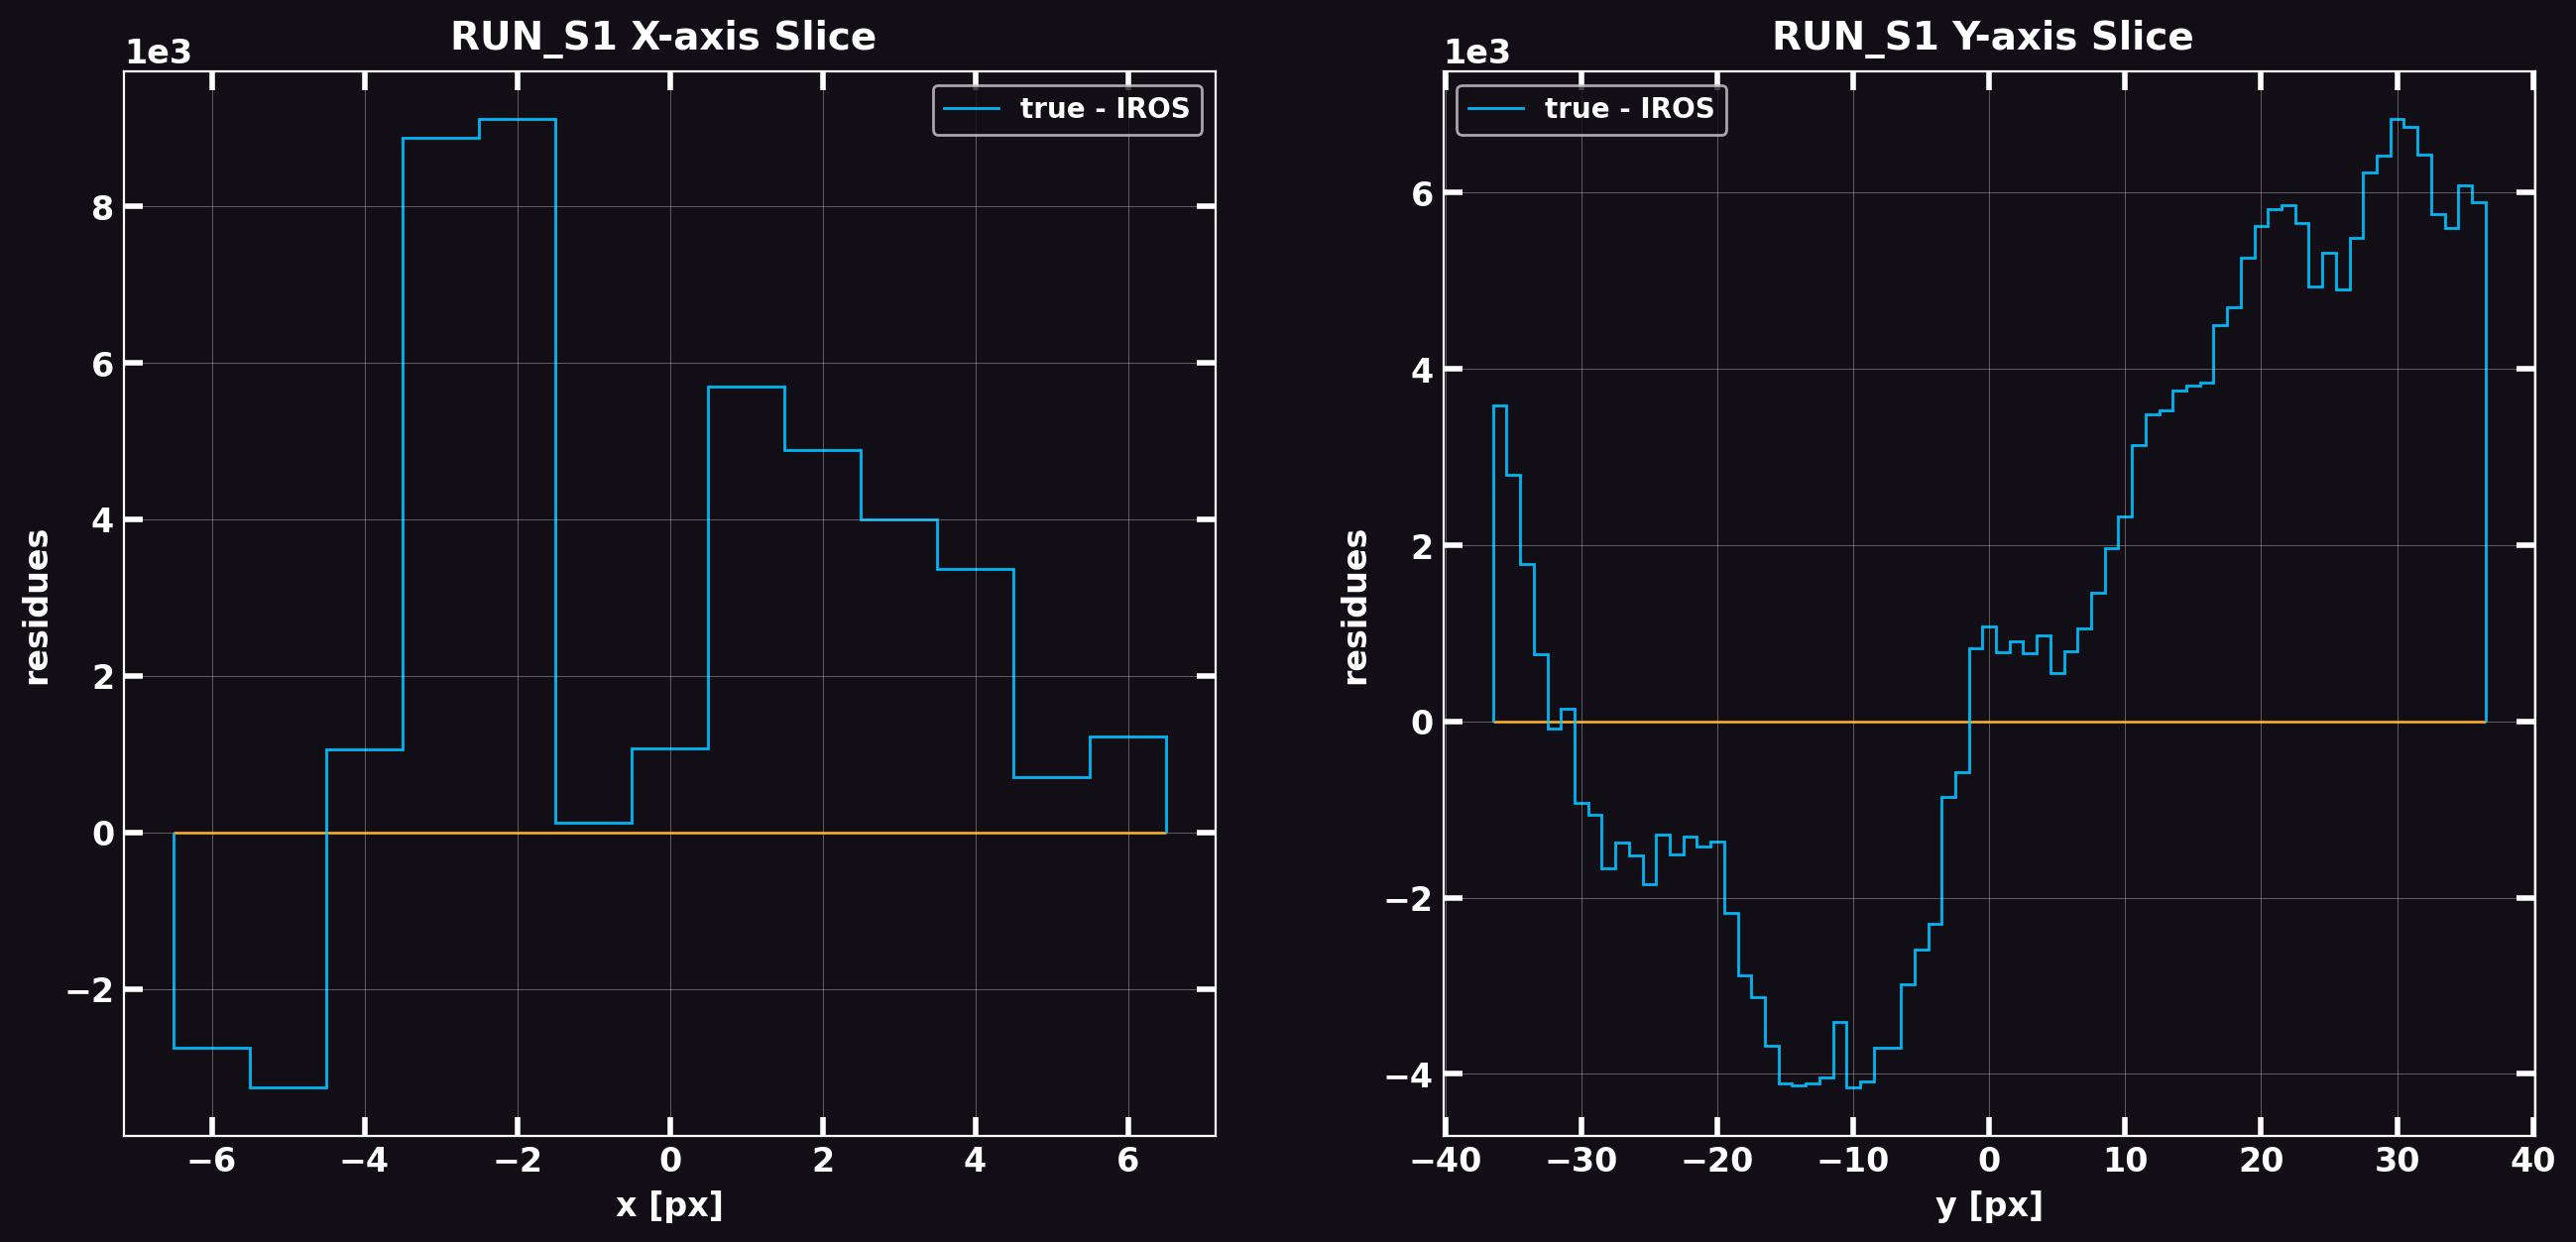

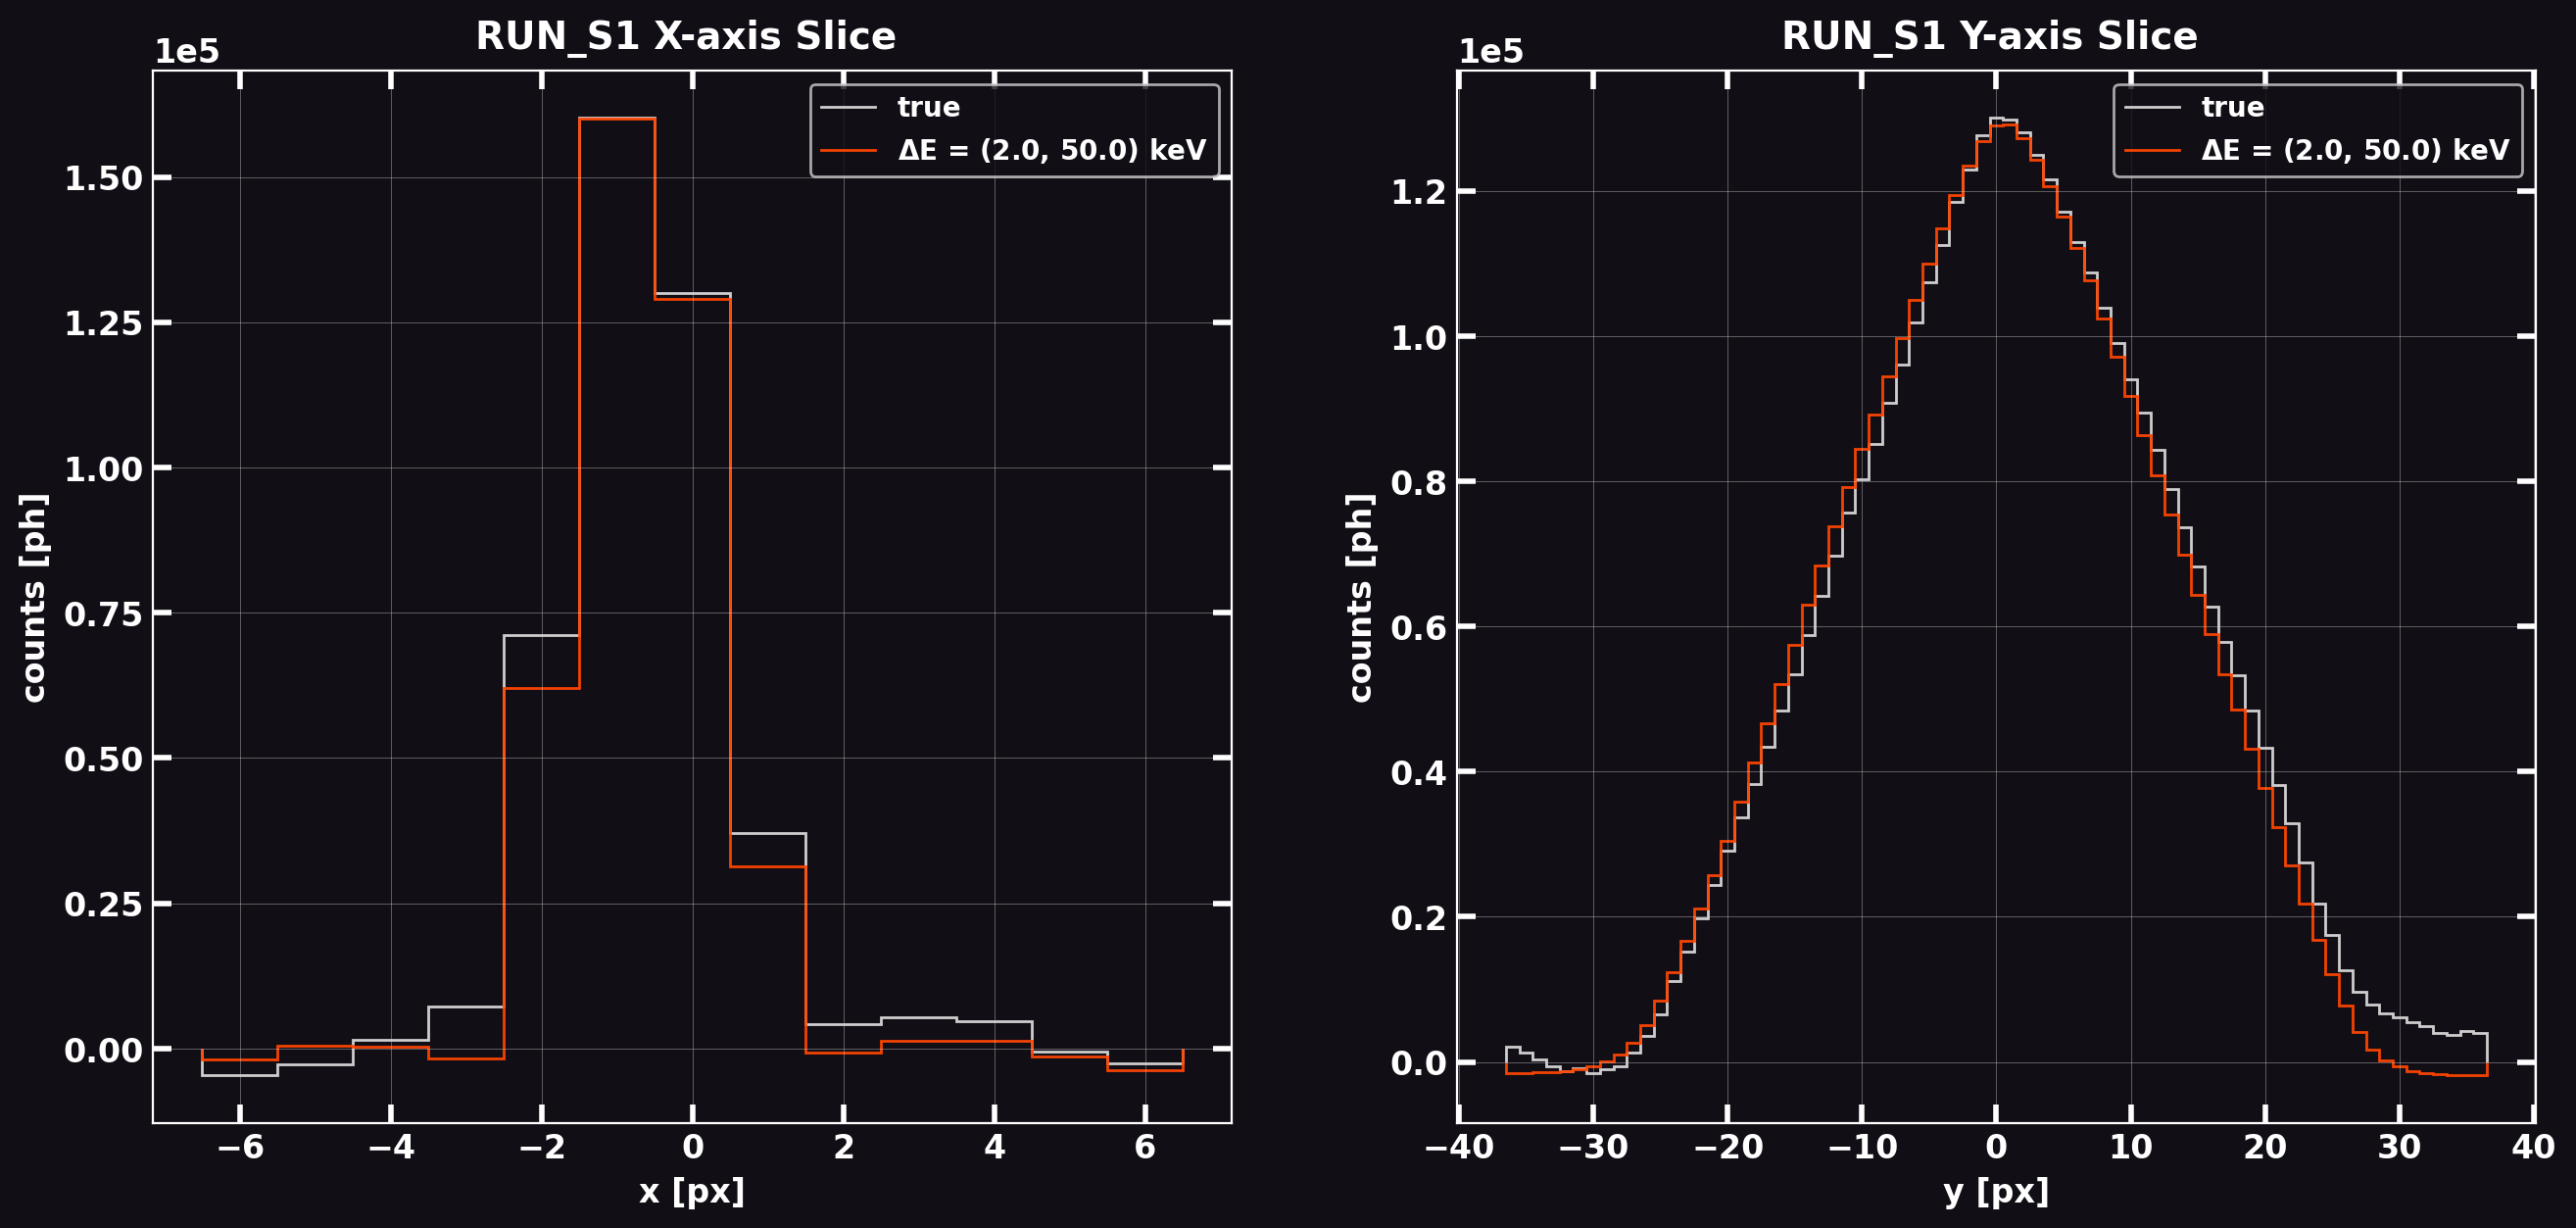

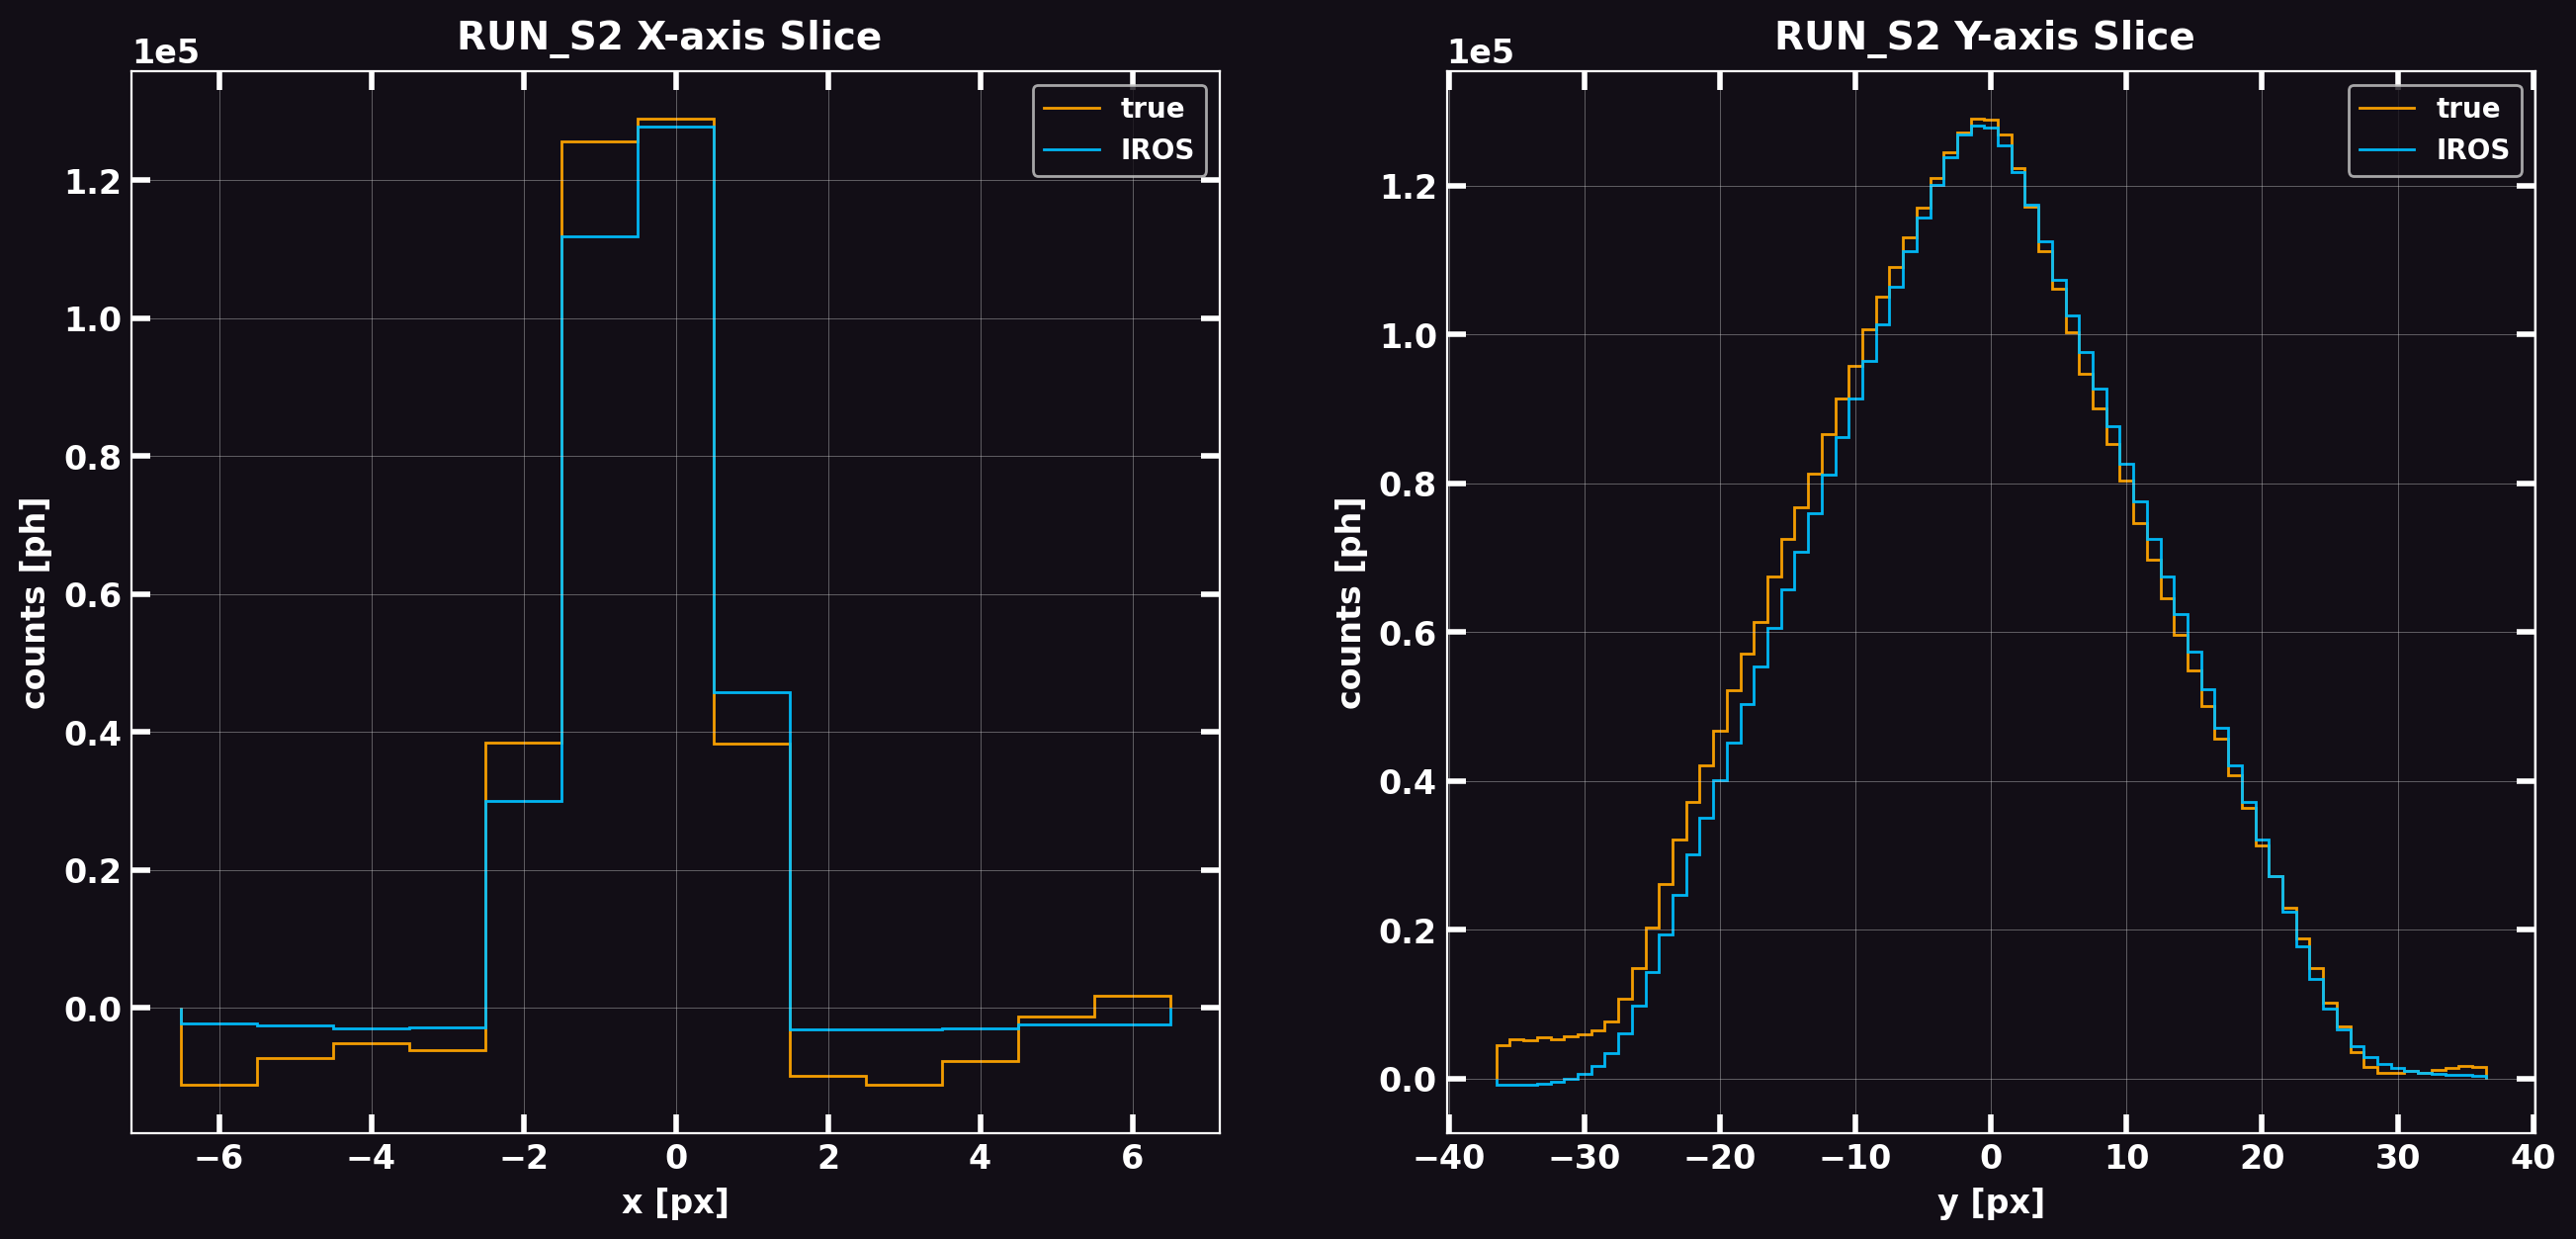

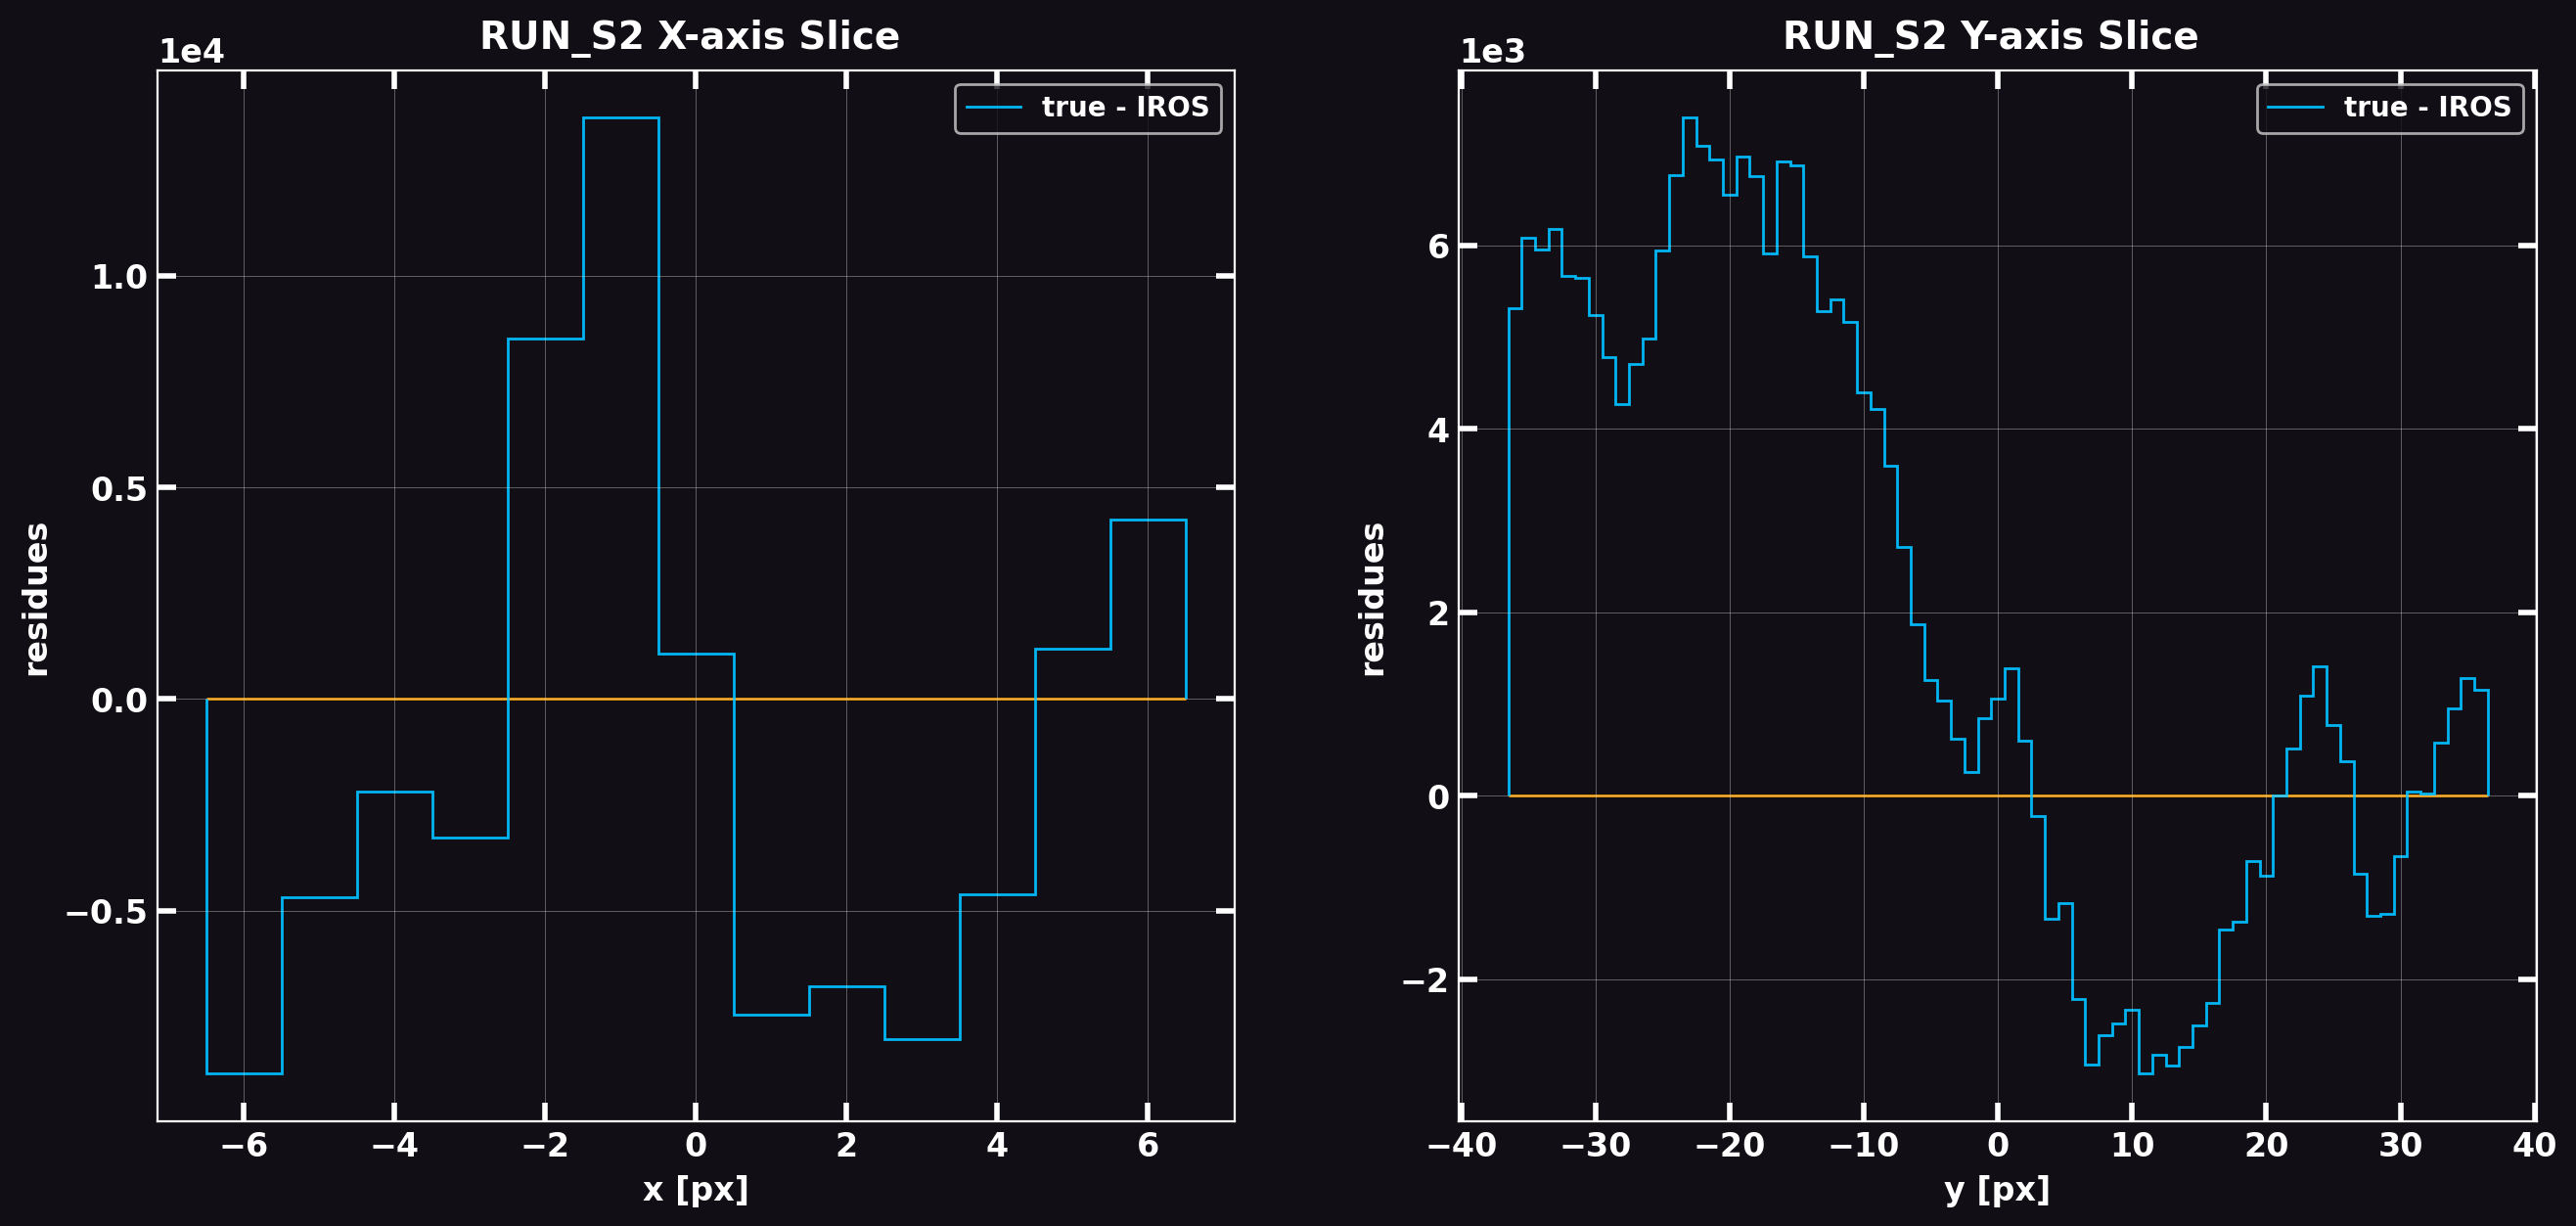

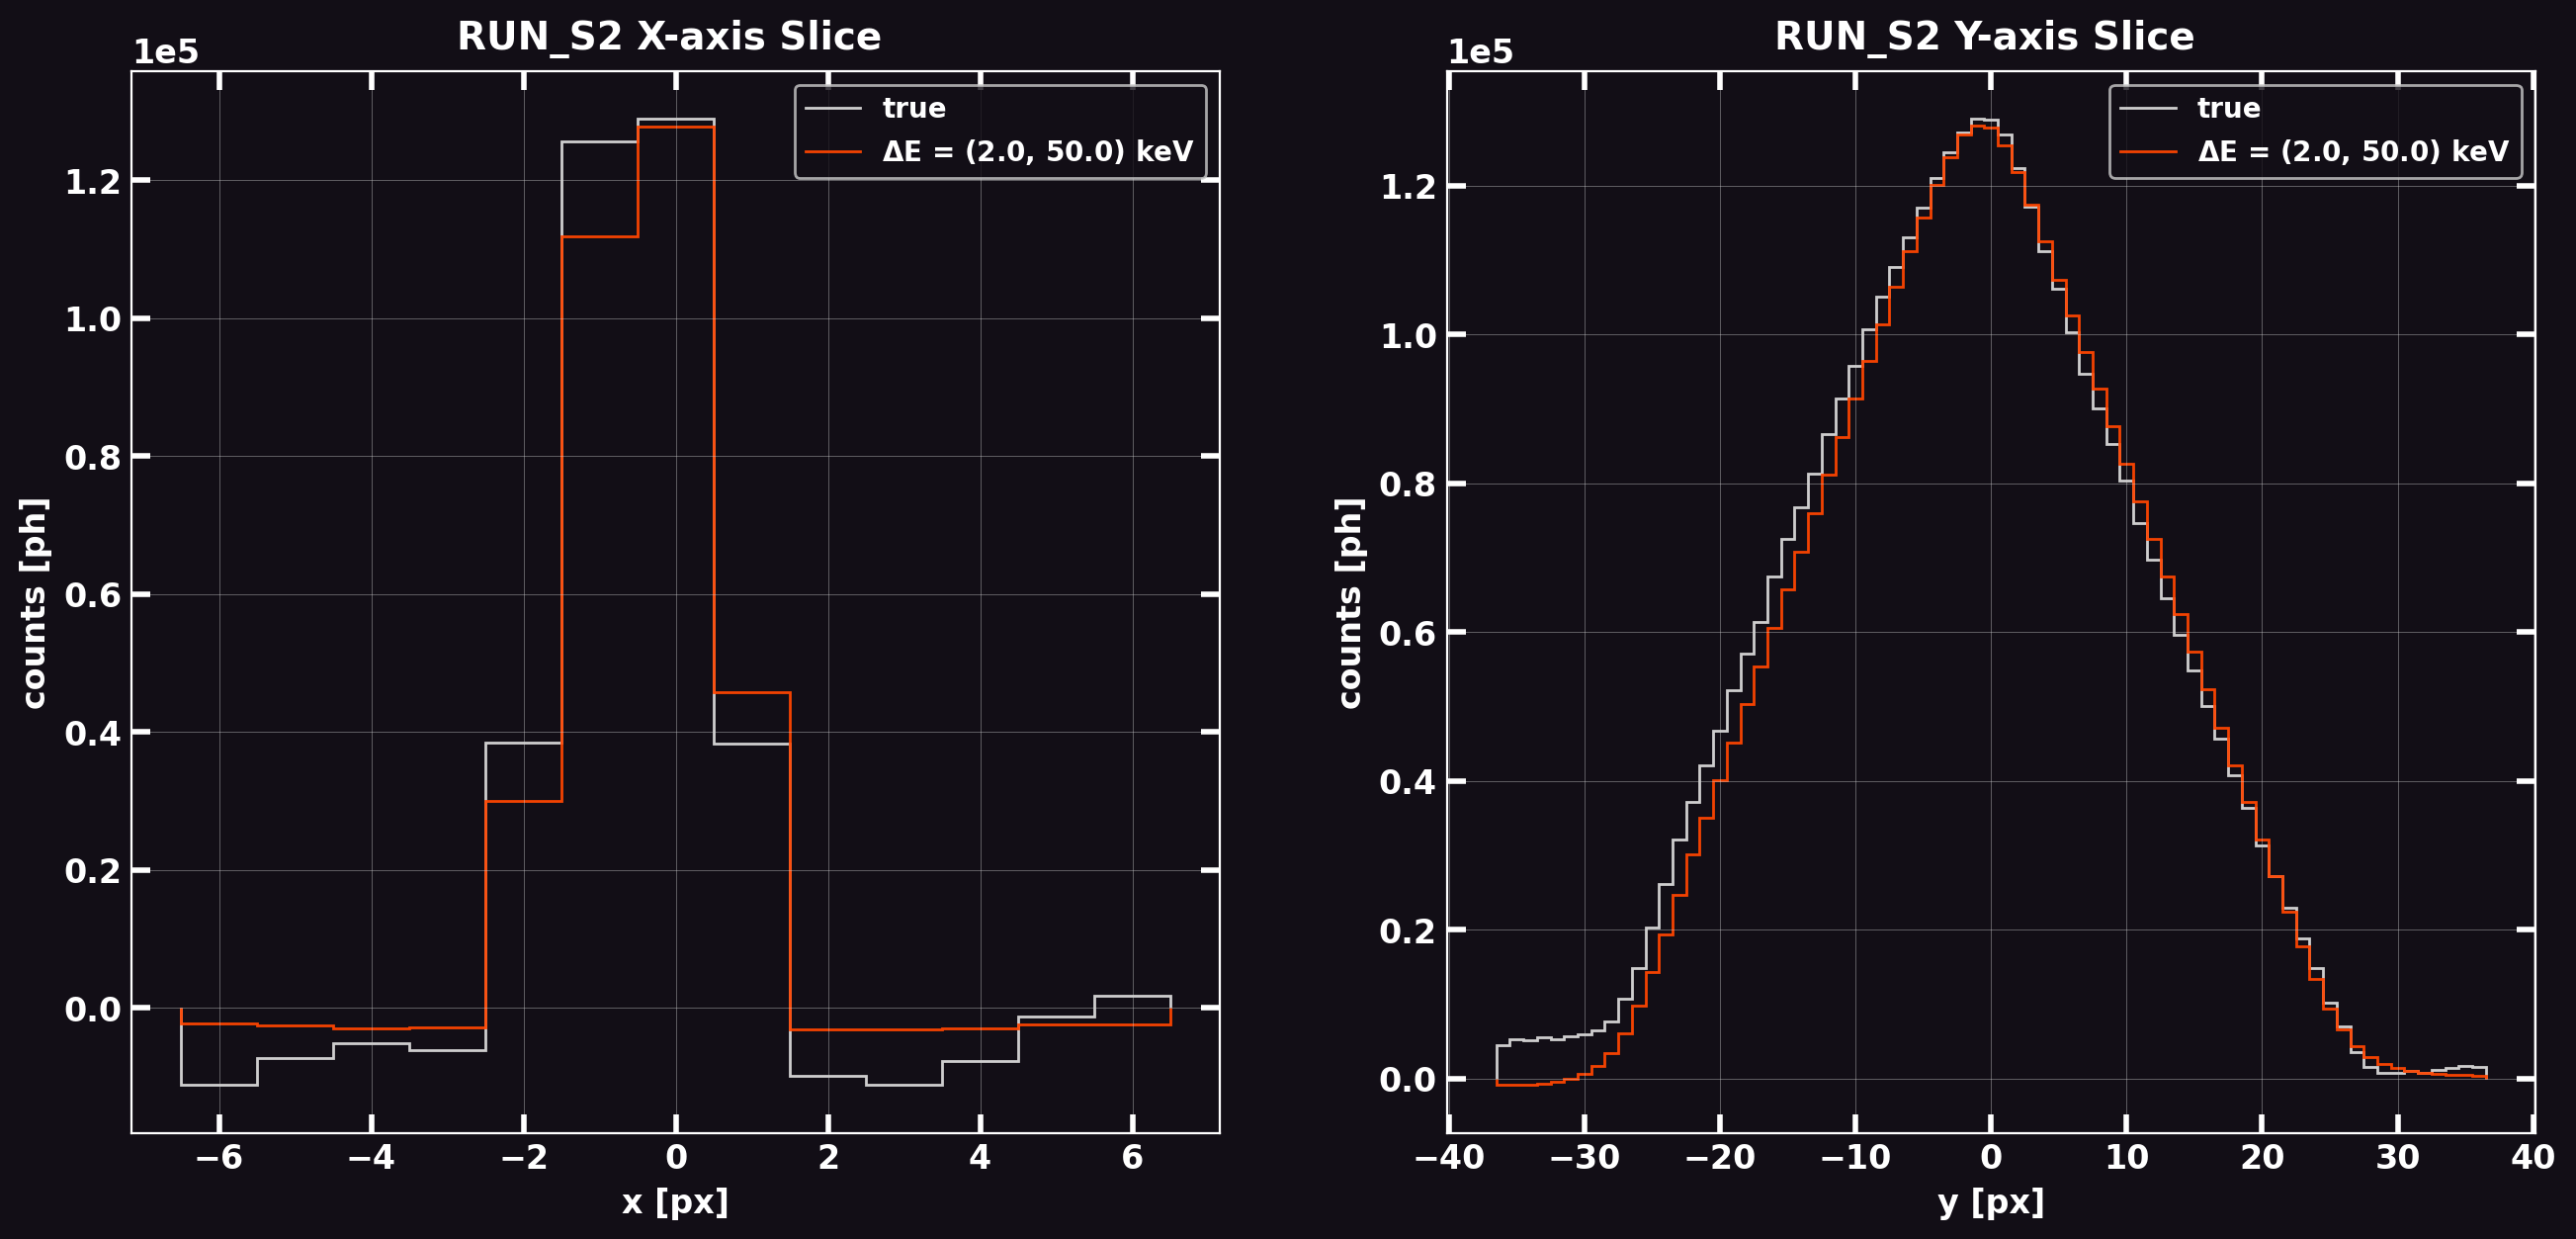

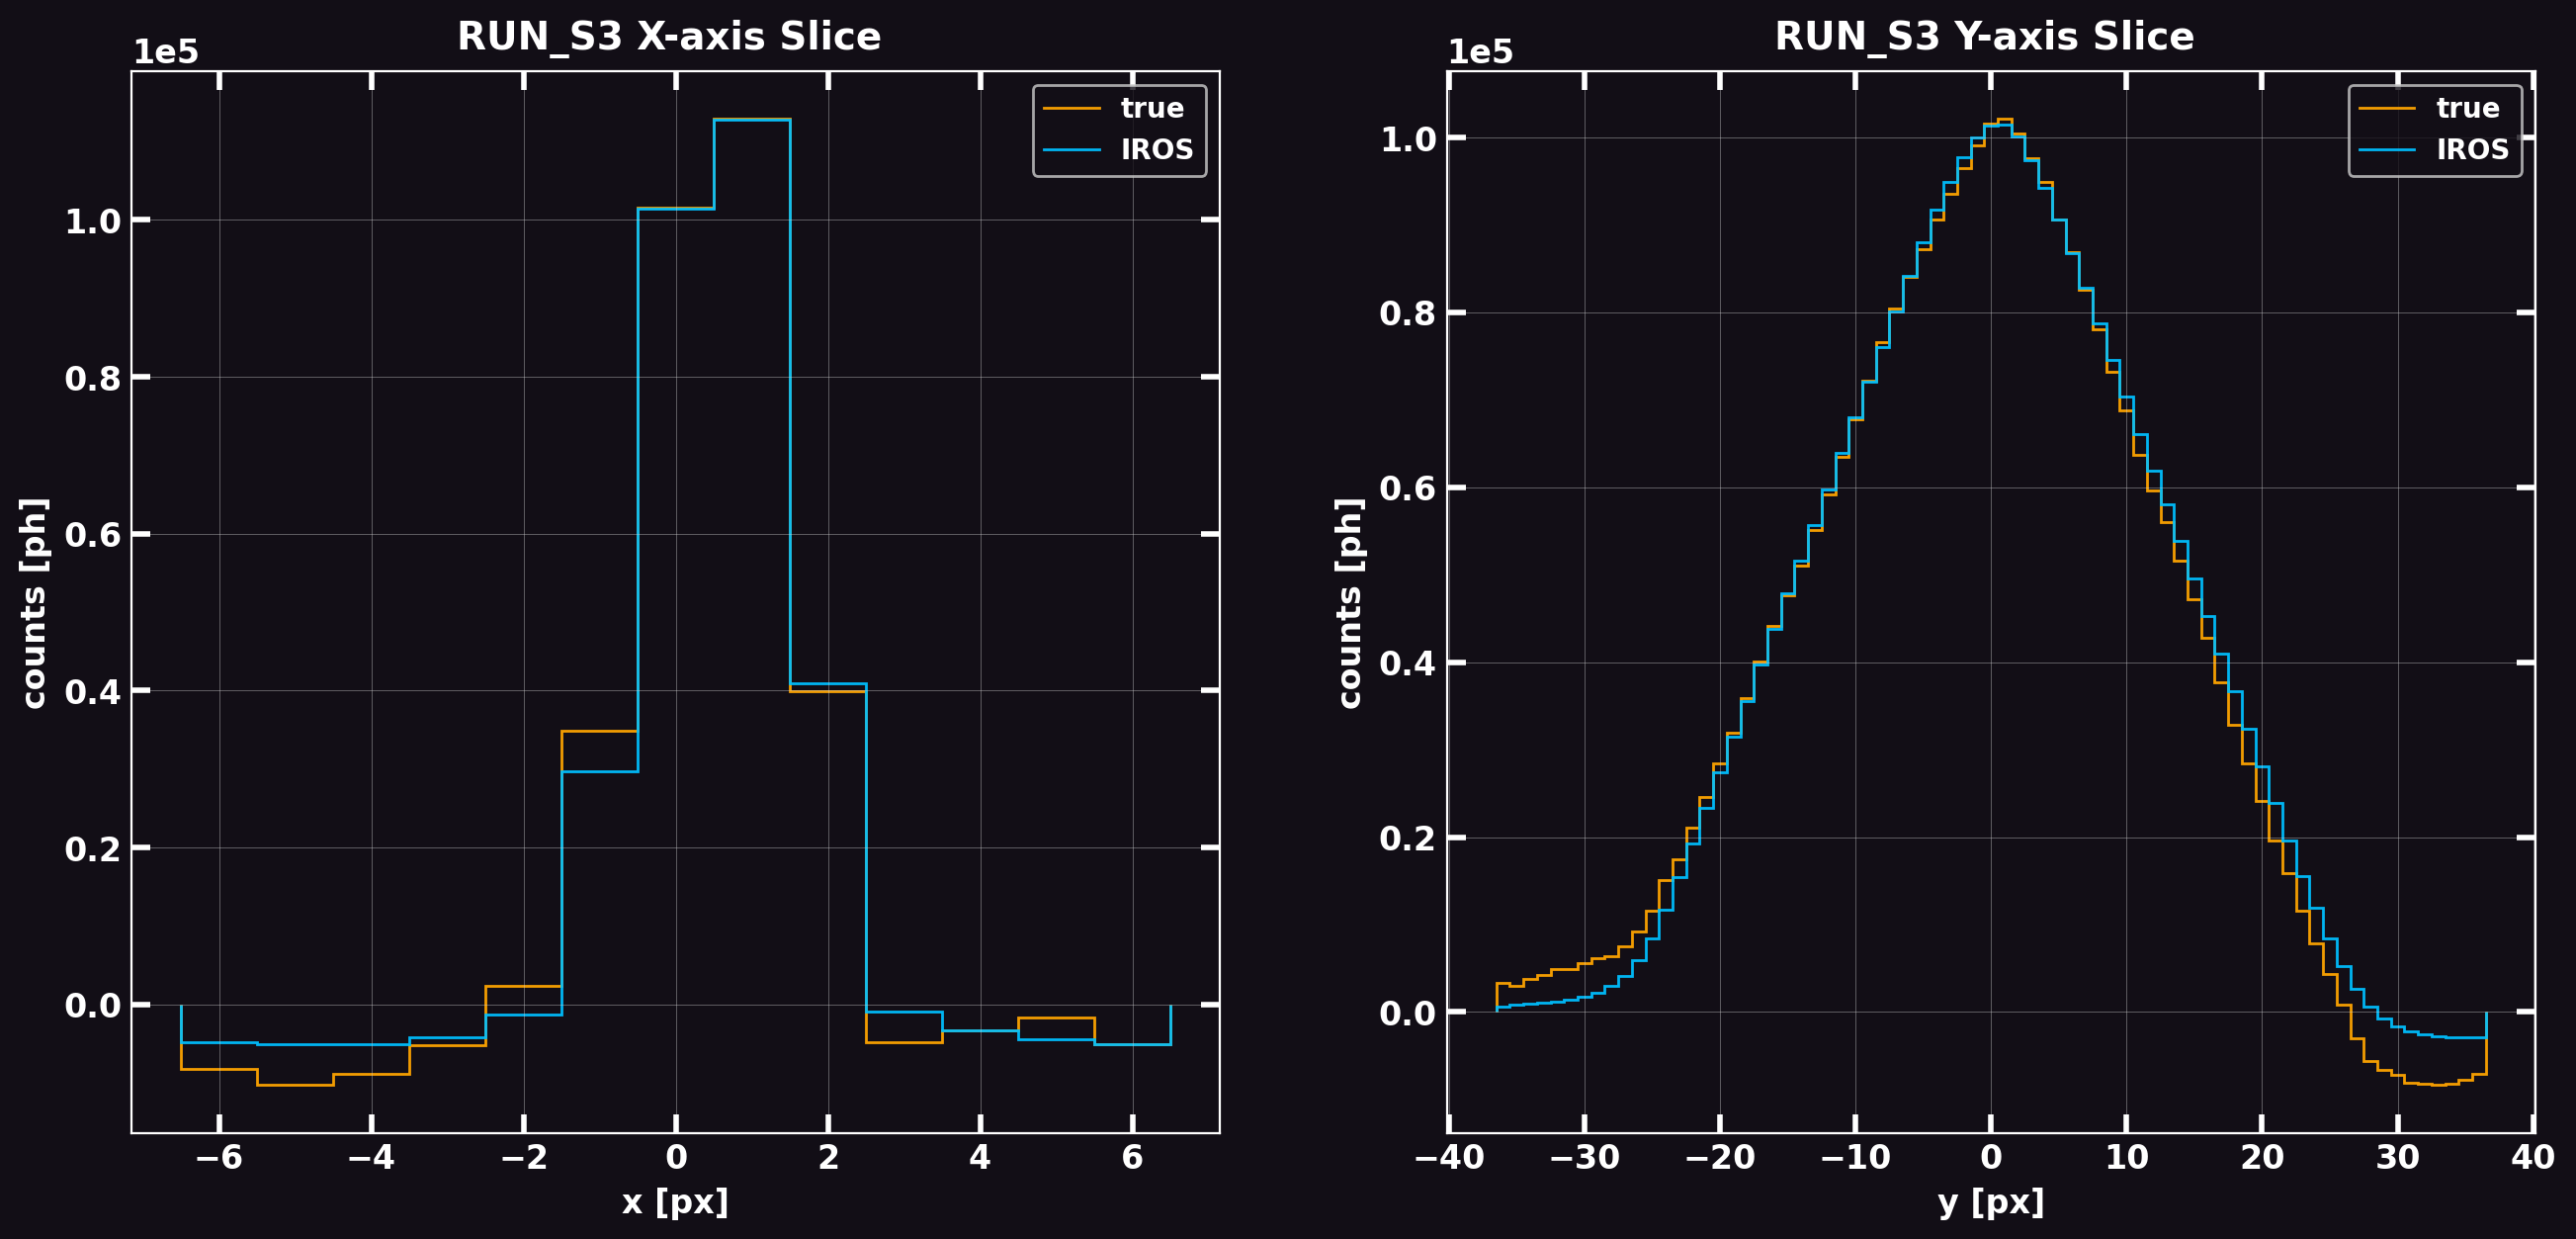

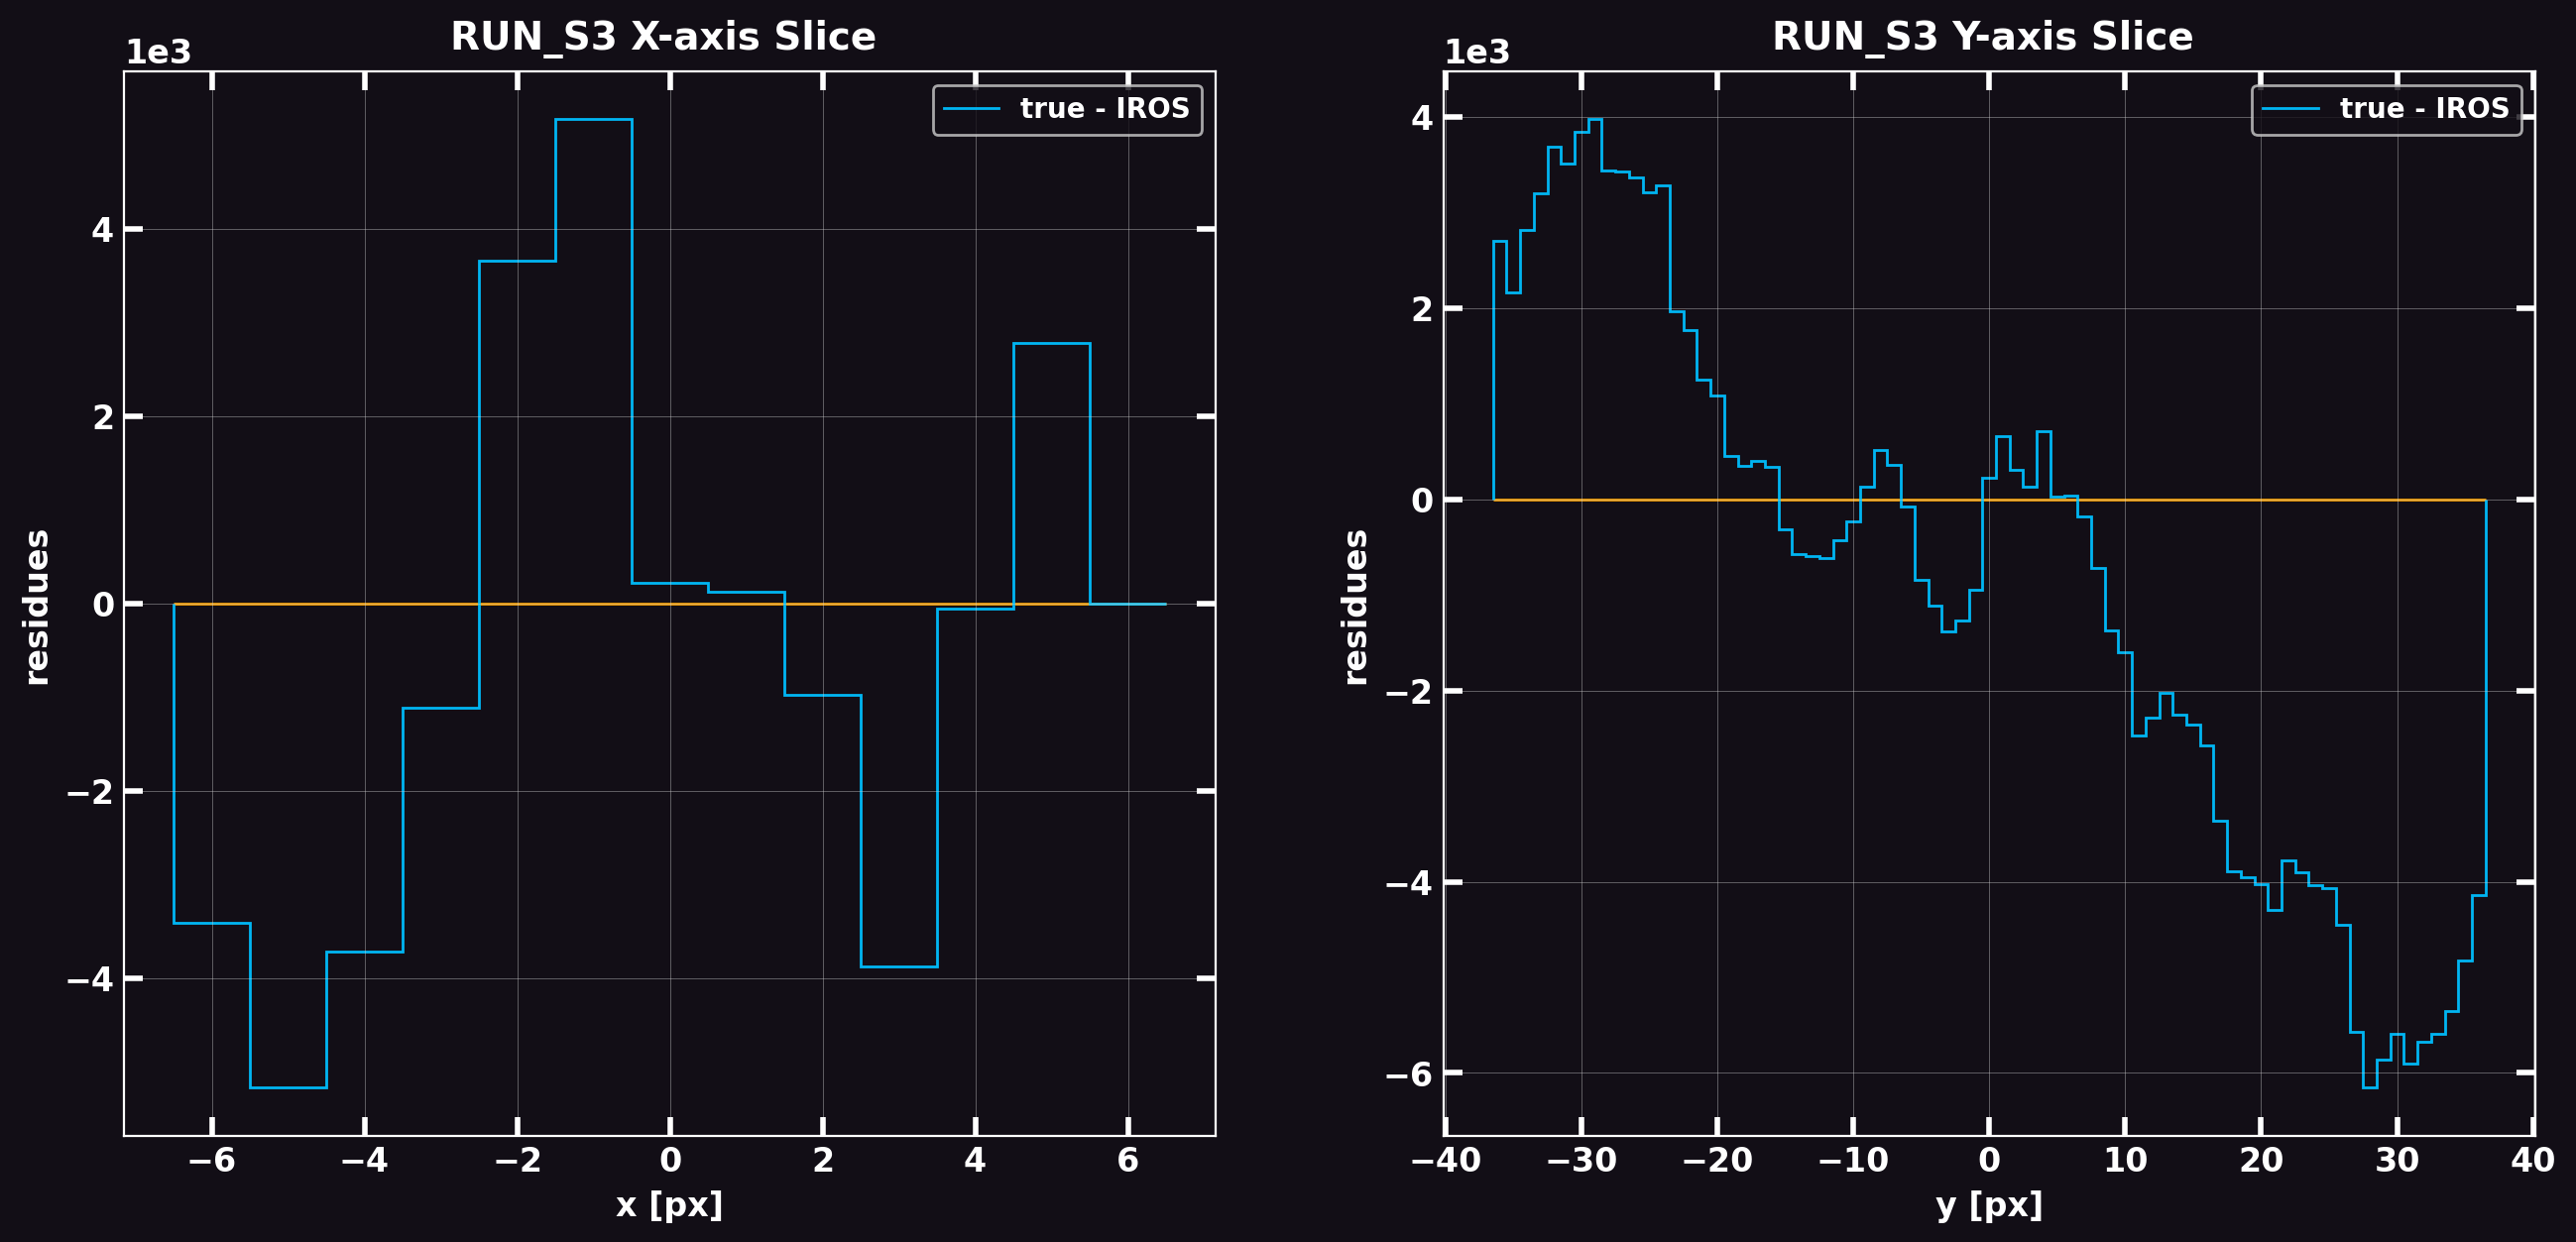

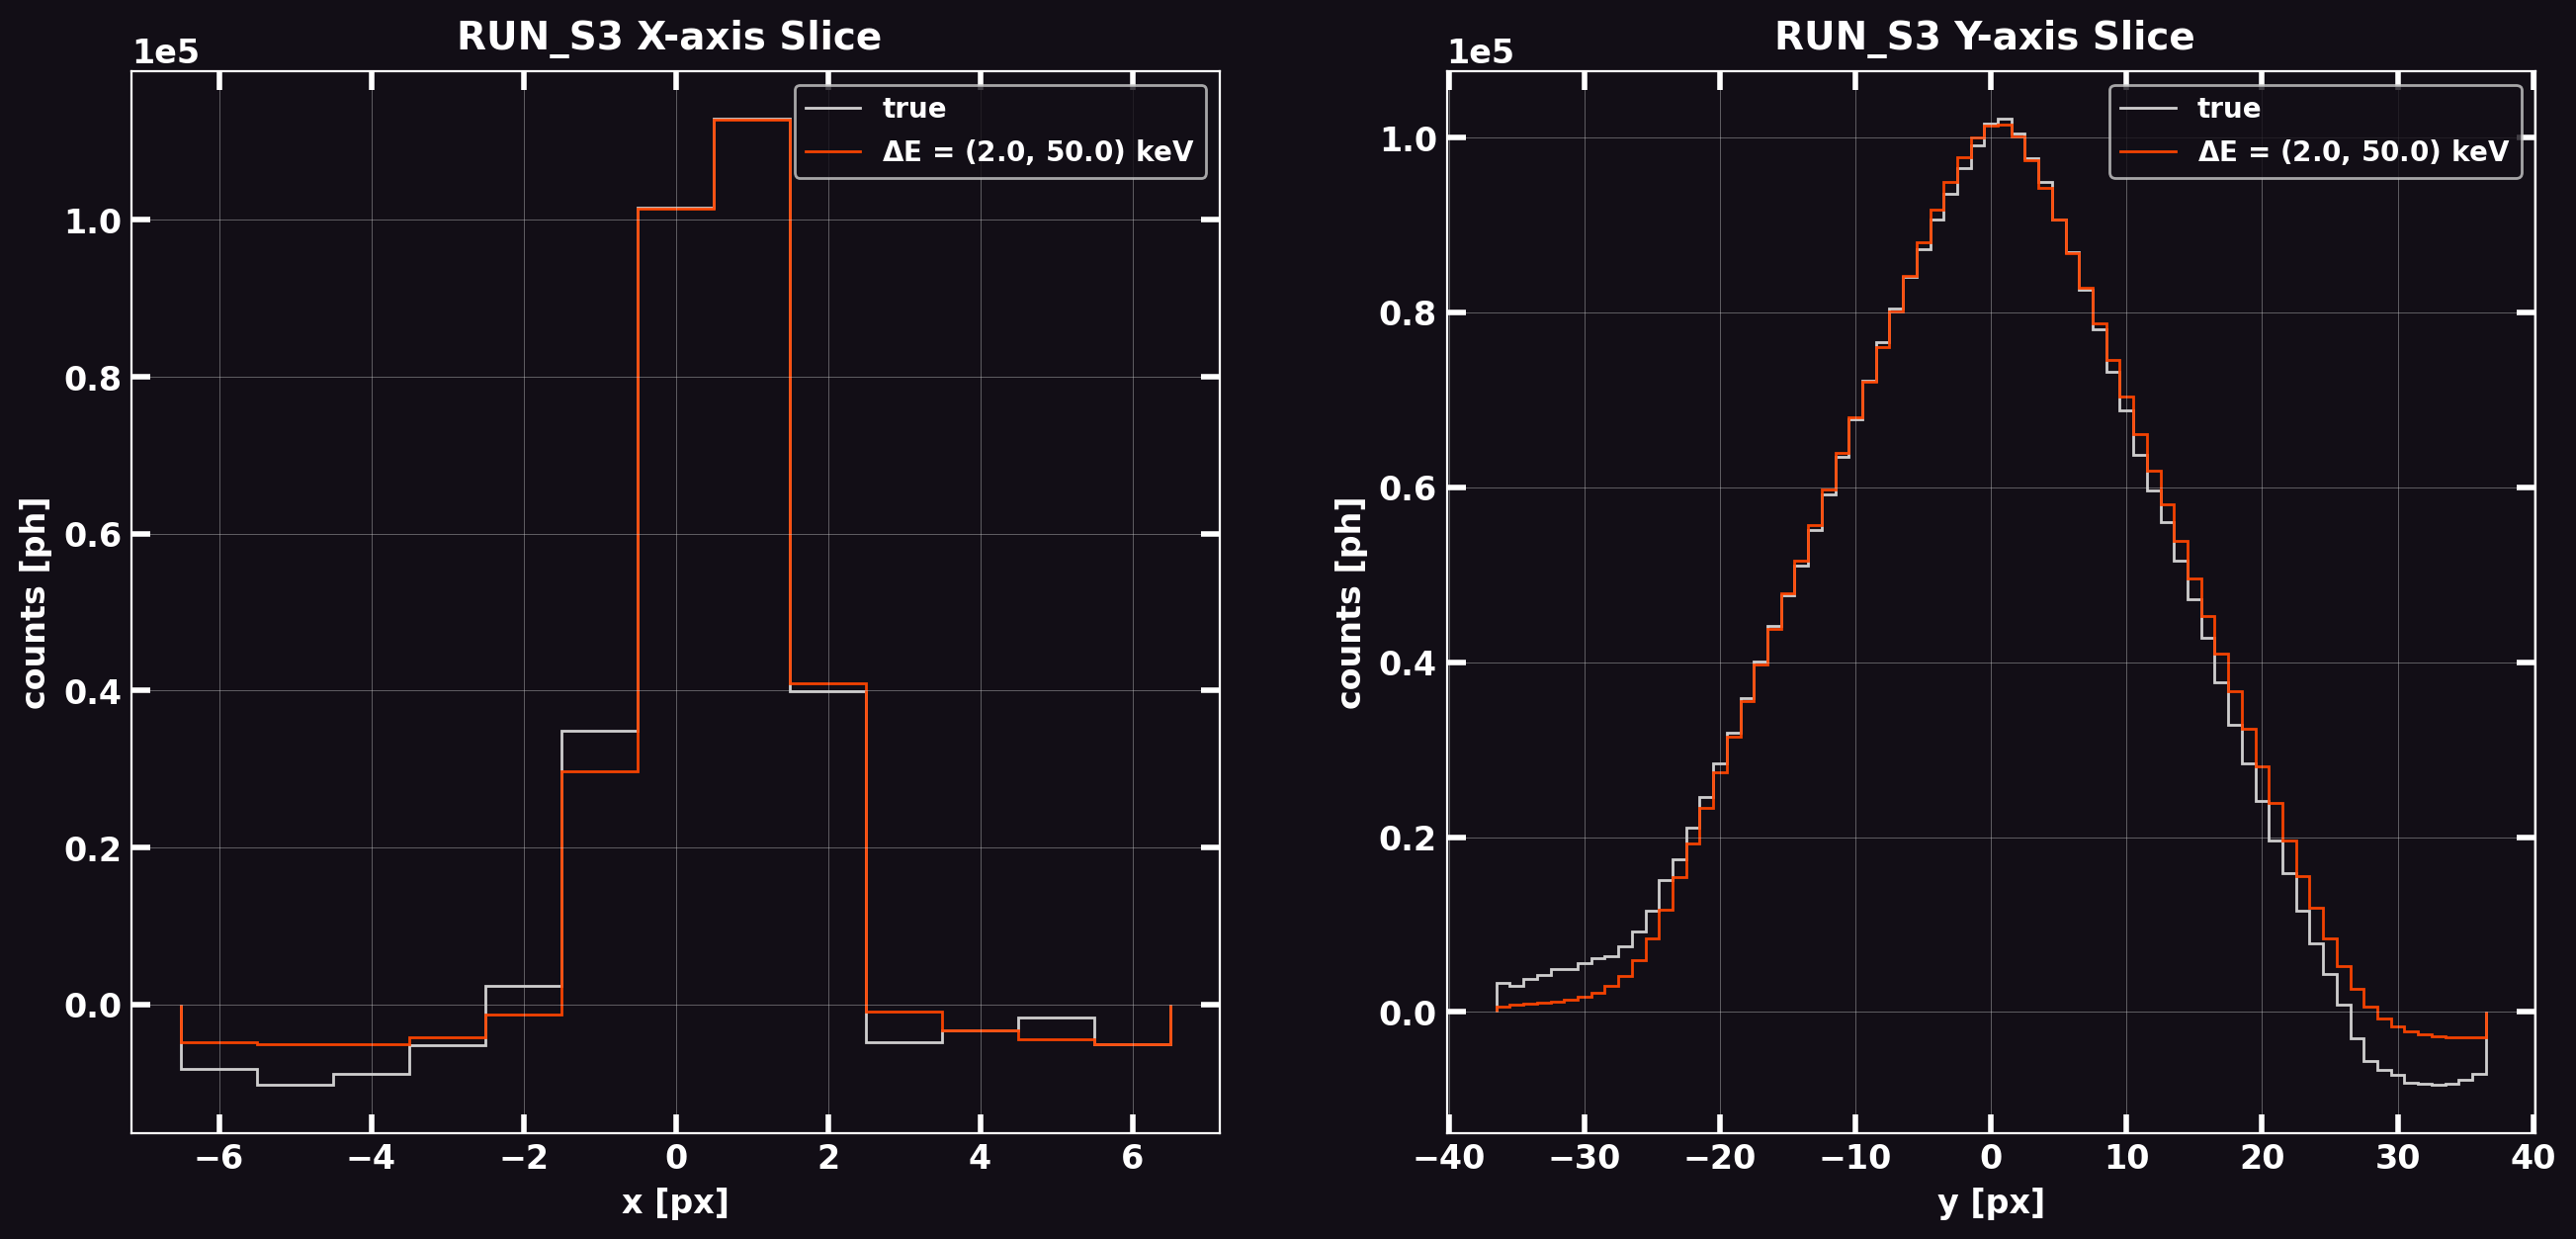

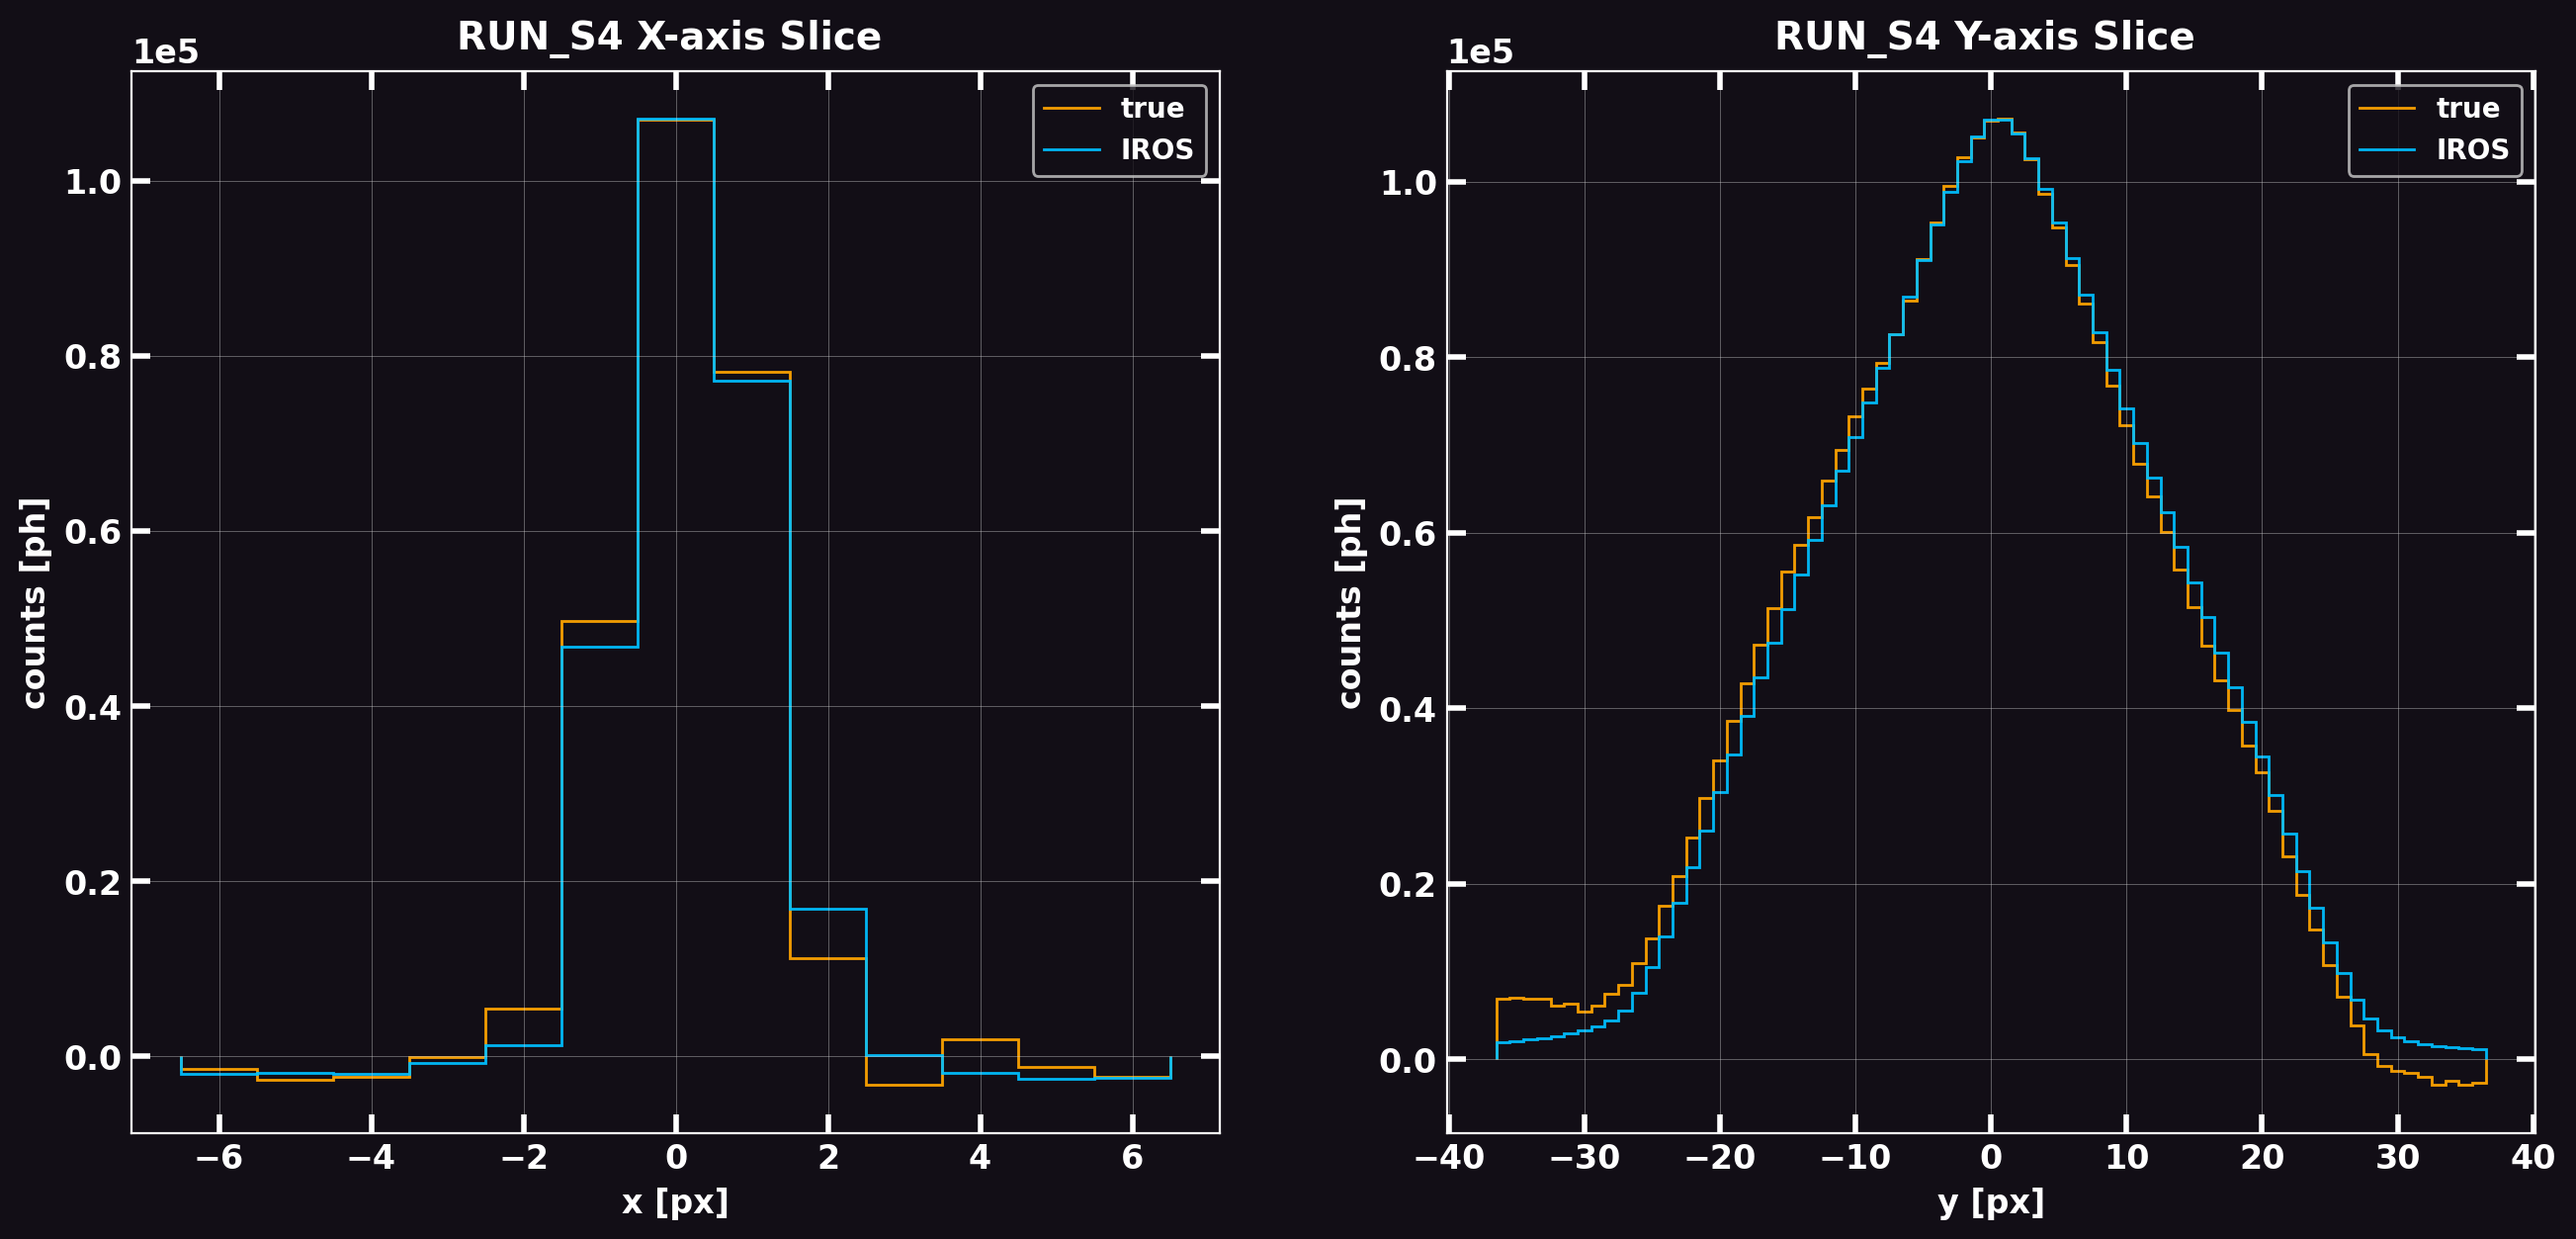

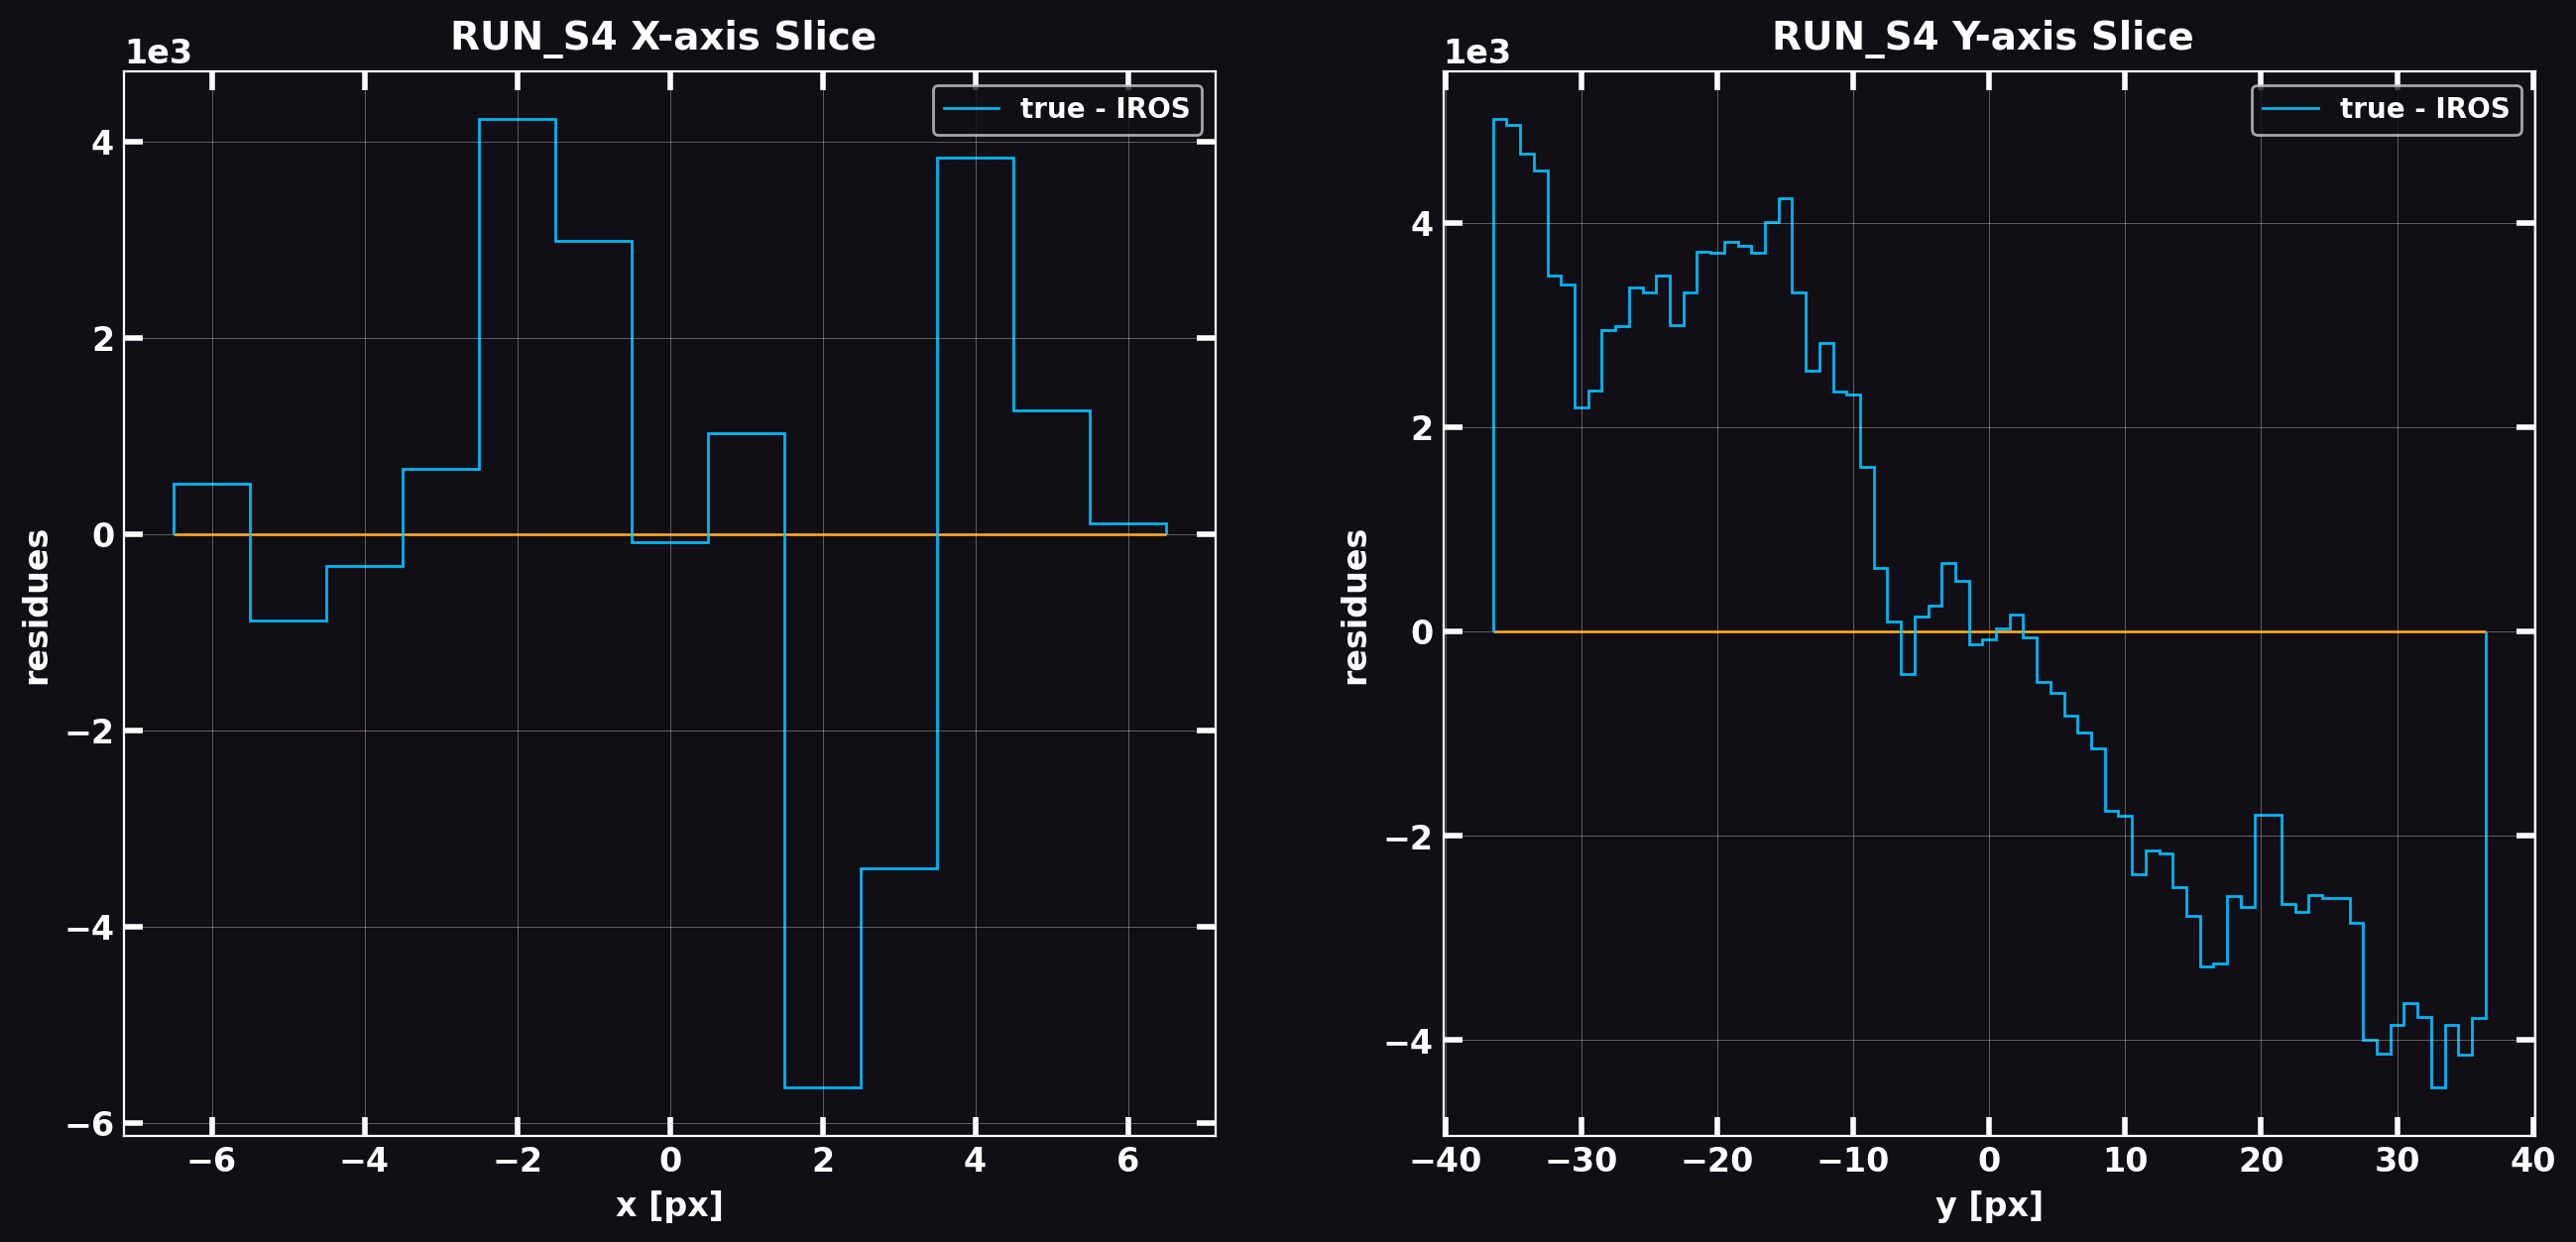

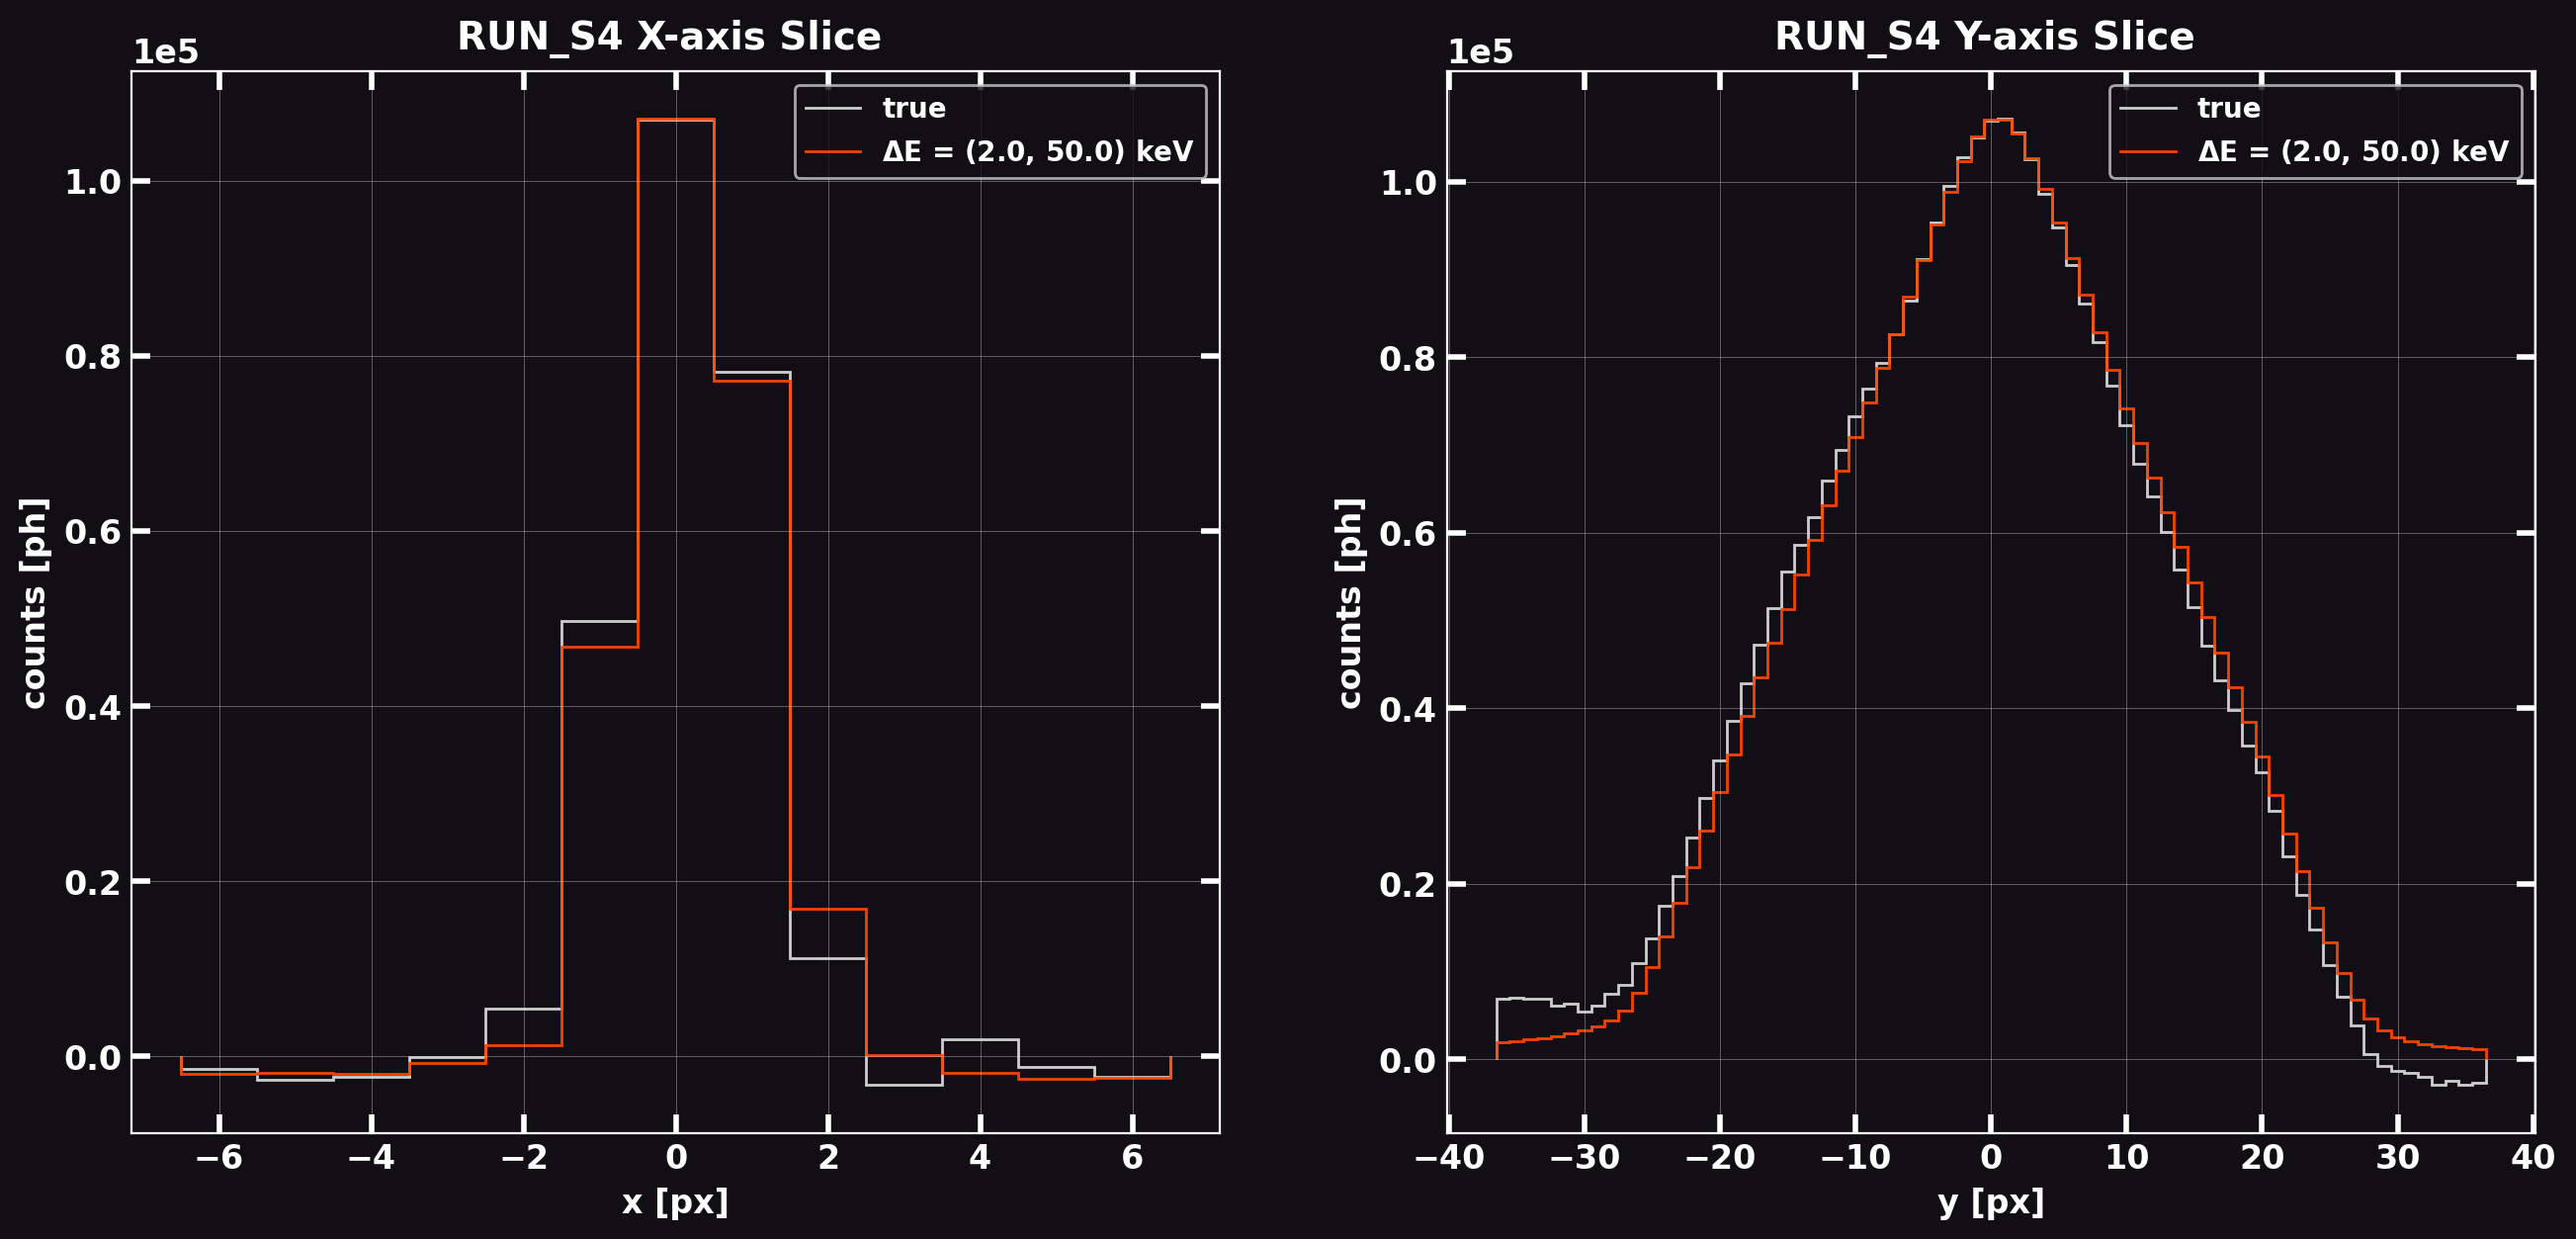

In [11]:
true_sky: NDArray = decode(wfm, detector)

save_to = None  #'/home/edoardo/Desktop/ebands_IROS_run'
plot_results(true_sky, candidates, wfm, energy_bands, save_to=save_to)